In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, wilcoxon
import plotly.express as px
import plotly.graph_objects as go
import nbformat

from scipy.stats import ttest_ind, f_oneway
import statsmodels.api as sm
import statsmodels.formula.api as smf
from matplotlib_venn import venn2
import os
from scipy.stats import mannwhitneyu

In [38]:
cell_types=["Tcells","Bcells",	"Fibroblasts", "NKcells", "Macrophages","Mast cells", "DCs", "other", "Endothelial cells","tumor"]
target_CAFs=["FAP", "PDGFRA", "PDGFRB", "S100A4", "LRRC15", "IL1R1", "IL1R2","SMO"]
target_receptors_molecules=["TGFB1","TGFB2","TGFB3", "TGFBR1","TGFBR2","TGFBR3","IL6", "IL6R", "IL10RA","IL10RB", "CXCL8", "CXCL12", 
 "CCR5", "CXCR2", "CXCR1", "CXCR4", "CXCL10","CXCL9","HGF", "MET", "FGF1","FGF2","FGF7","FGF10", "FGFR1","FGFR2","FGFR3","FGFR4","IL11","HAS1","HAS2","HYAL1","HYAL2"]
fibr_gene_expression_modified=pd.read_csv("/Users/nikamikhailava/Desktop/batch_merged_new/fibroblasts_gene_expression_data_new_batch_merged_with_metadata.csv")
clinical_data=pd.read_csv("/Users/nikamikhailava/Desktop/batch_merged/9_eyemt_patient_clinical_data_new.csv")
fibr_gene_expression_modified["Patient"]=fibr_gene_expression_modified["Sample"].str.extract(r'(S\d+)')
fibr_gene_expression_modified=fibr_gene_expression_modified.merge(clinical_data[["Patient","PFS_quartile_b12"]],on="Patient", how="left")
fibr_gene_expression_modified=fibr_gene_expression_modified.merge(clinical_data[["Patient","OS_quartile_b12"]],on="Patient", how="left")
fibr_gene_expression_modified=fibr_gene_expression_modified.drop_duplicates().reset_index(drop=True)
print(len(fibr_gene_expression_modified))
df_cell_abundance = pd.read_csv("/Users/nikamikhailava/Desktop/batch_merged/batch_merged_bp_res_mid_lvl_ct_ct_fraction.csv")
fibr_gene_expression_cell_abundance=fibr_gene_expression_modified.merge(df_cell_abundance, on="dcc_filename", how="left")
fibr_gene_expression_cell_abundance

444


,dcc_filename,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,HES4,ISG15,AGRN,RNF223,...,Endothelial cells,Roi_y,Segment_y,Sample_y,NACT_status_y,Annotation_cell_y,Roi.1,Segment_geomx,Patient_y,Site_y
0,DSP-1001660016604-A-A02.dcc,1.395991,1.907436,1.506498,1.700645,-0.045271,2.111774,4.080095,1.987522,-0.088093,...,0.028128,1.0,stroma,S130_iOme,post,CD8_Iba1,NaN,tsi,S130,Omentum
1,DSP-1001660016604-A-A03.dcc,1.260101,1.487834,1.372068,0.897518,1.051446,1.981081,4.439861,1.858659,-0.088057,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,DSP-1001660016604-A-A04.dcc,1.224783,1.724003,1.333149,1.528053,-0.045955,1.932914,5.415247,1.805880,-0.088144,...,0.029949,2.0,stroma,S130_iOme,post,CD8_CD11_Iba1,NaN,tsi,S130,Omentum
3,DSP-1001660016604-A-A05.dcc,1.032495,1.168011,1.440325,0.954786,-0.044855,1.752843,5.293798,1.926242,-0.088061,...,0.029244,2.0,tumor,S130_iOme,post,CD8_CD11_Iba1,NaN,tsi,S130,Omentum
4,DSP-1001660016604-A-A06.dcc,0.885513,1.403719,0.997214,1.190924,-0.044885,2.324255,5.864764,1.482811,-0.088064,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
439,DSP-1001660037247-C-D01.dcc,1.437959,1.440393,1.436729,1.241617,-0.193169,1.637498,3.101474,1.641694,-0.090027,...,0.042210,17.0,stroma,S333_pOme,pre,CD4_CD8_Iba1,NaN,stroma,S333,Omentum
440,DSP-1001660037247-C-D02.dcc,0.945847,1.243403,0.944546,0.748442,0.529108,1.884311,5.777772,1.685343,-0.090014,...,0.016802,18.0,stroma,S333_pOme,pre,CD8_CD11_Iba1,NaN,tsi,S333,Omentum
441,DSP-1001660037247-C-D03.dcc,-0.115866,0.009407,-0.109719,-0.209418,-0.136728,0.308744,7.235237,0.261484,-0.091188,...,0.010118,18.0,tumor,S333_pOme,pre,CD8_CD11_Iba1,NaN,tsi,S333,Omentum
442,DSP-1001660037247-C-D04.dcc,0.912336,1.440847,0.911072,-0.369284,-0.193441,1.110790,4.140232,1.641895,-0.090021,...,0.012752,19.0,stroma,S333_pOme,pre,CD8_CD11_Iba1,NaN,tsi,S333,Omentum


In [39]:
fibr_gene_expression_cell_abundance["PFS_HL_group"] = fibr_gene_expression_cell_abundance["PFS_quartile_b12"].apply(
    lambda x: "Low" if x in [1, "1", 2, "2"] else ("High" if x in [3, "3", 4, "4"] else None)
)
fibr_gene_expression_cell_abundance["OS_HL_group"] = fibr_gene_expression_cell_abundance["OS_quartile_b12"].apply(
    lambda x: "Low" if x in [1, "1", 2, "2"] else ("High" if x in [3, "3", 4, "4"] else None)
)

In [40]:
fibr_gene_expression_cell_abundance=fibr_gene_expression_cell_abundance[fibr_gene_expression_cell_abundance["NACT_status_y"]=="post"]

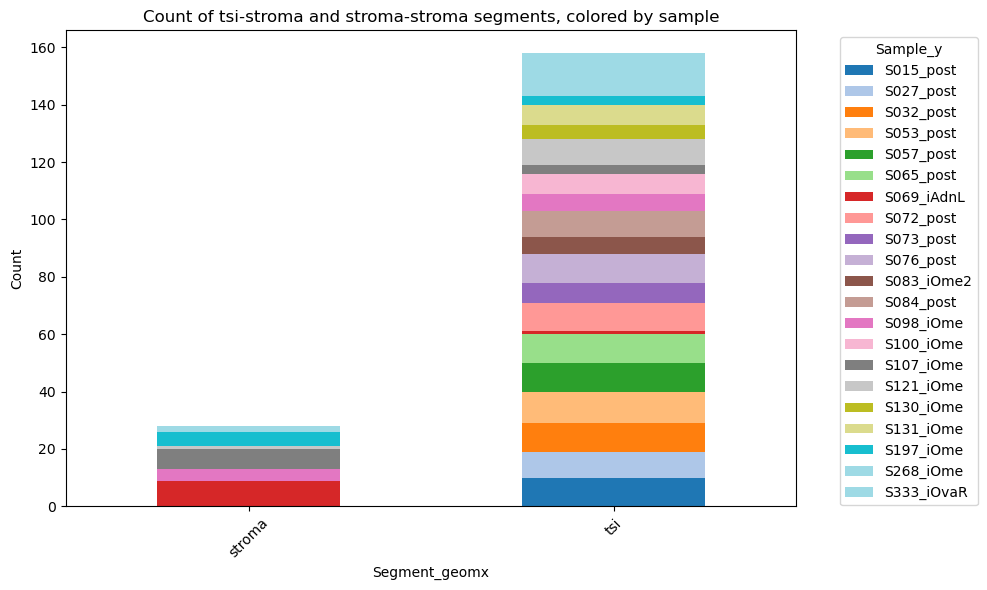

In [41]:
comb_counts = fibr_gene_expression_cell_abundance.groupby(
    ['Segment_geomx', 'Segment_y', 'Sample_y']
).size().reset_index(name='count')

# Step 2: Filter to only Segment_y == "stroma"
comb_counts = comb_counts[comb_counts["Segment_y"] == "stroma"]

# Step 3: Pivot the data so each Sample_y becomes a column
pivot_df = comb_counts.pivot_table(
    index='Segment_geomx',
    columns='Sample_y',
    values='count',
    fill_value=0
)

# Step 4: Plot as stacked bar chart
pivot_df.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    colormap='tab20'  # optional color palette
)

plt.title("Count of tsi-stroma and stroma-stroma segments, colored by sample")
plt.xlabel("Segment_geomx")
plt.ylabel("Count")
plt.legend(title='Sample_y', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [42]:
df_cell_abundance["Segment_geomx"].value_counts()

Segment_geomx
tsi       456
stroma     36
tumor      12
Name: count, dtype: int64

In [43]:
df_cell_abundance.head()

,dcc_filename,tumor,Tcells,Bcells,Fibroblasts,NKcells,Macrophages,Mast cells,DCs,other,Endothelial cells,Roi,Segment,Sample,NACT_status,Annotation_cell,Roi.1,Segment_geomx,Patient,Site
0,DSP-1001660016606-G-A02.dcc,0.476461,0.009487,0.135361,0.231508,0.018543,0.101739,0.001637,0.014749,NaN,0.010419,1,stroma,S053_post,post,posCD8_posIBA1,1.0,tsi,S053,Omentum
1,DSP-1001660016606-G-A03.dcc,0.806981,0.013774,0.026948,0.064725,0.012740,0.055951,0.001264,0.009905,NaN,0.007552,1,tumor,S053_post,post,posCD8_posIBA1,1.0,tsi,S053,Omentum
2,DSP-1001660016606-G-A04.dcc,0.427201,0.009367,0.105530,0.250796,0.012980,0.169353,NaN,0.018545,NaN,0.005558,2,stroma,S053_post,post,posCD8_posIBA1,2.0,tsi,S053,Omentum
3,DSP-1001660016606-G-A05.dcc,0.879490,0.005288,0.010088,0.017065,0.012011,0.058875,0.000828,0.010556,NaN,0.005297,2,tumor,S053_post,post,posCD8_posIBA1,2.0,tsi,S053,Omentum
4,DSP-1001660016606-G-A06.dcc,0.450971,0.015423,0.058719,0.276402,0.017479,0.127136,0.000578,0.023020,NaN,0.030219,3,stroma,S053_post,post,posCD8_posIBA1,3.0,tsi,S053,Omentum


In [44]:
# Extract sample metadata
sample_metadata = fibr_gene_expression_cell_abundance[["Sample_y", "PFS_HL_group", "OS_HL_group"]].drop_duplicates().set_index("Sample_y")

# Properly filter for stroma + Segment_geomx == 'tsi'
stroma_cell_abundance = fibr_gene_expression_cell_abundance[
    (fibr_gene_expression_modified['Segment'] == 'stroma') & 
    (fibr_gene_expression_cell_abundance['Segment_geomx'] == 'stroma')
]

# Seems to be the same filter as above — do you really need both?
stroma_tsi_cell_abundance = fibr_gene_expression_cell_abundance[
    (fibr_gene_expression_modified['Segment'] == 'stroma') & 
    (fibr_gene_expression_cell_abundance['Segment_geomx'] == 'tsi')
]

# Group by Sample_y and compute mean abundance
average_stroma_cell_abundance_stroma = stroma_cell_abundance.groupby('Sample_y')[cell_types].mean()
average_stroma_cell_abundance_tsi = stroma_tsi_cell_abundance.groupby('Sample_y')[cell_types].mean()

# Join with metadata
stroma = average_stroma_cell_abundance_stroma.join(sample_metadata, how="inner")
tsi = average_stroma_cell_abundance_tsi.join(sample_metadata, how="inner")



/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_4458/1219272017.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  stroma_cell_abundance = fibr_gene_expression_cell_abundance[
/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_4458/1219272017.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  stroma_tsi_cell_abundance = fibr_gene_expression_cell_abundance[


In [45]:
stroma["Segment"] = "Stroma"
tsi["Segment"] = "TSI"

# Step 3: Combine both DataFrames
combined = pd.concat([stroma, tsi])

In [46]:
combined.reset_index(inplace=True)

In [47]:
print(combined)

      Sample_y    Tcells    Bcells  Fibroblasts   NKcells  Macrophages  \
0   S069_iAdnL  0.045512  0.128406     0.104103  0.029824     0.155395   
1    S098_iOme  0.048767  0.110966     0.151214  0.032128     0.185954   
2    S107_iOme  0.022030  0.051545     0.245530  0.027953     0.220317   
3    S121_iOme  0.065329  0.048056     0.133609  0.047979     0.095352   
4    S197_iOme  0.040030  0.008969     0.177433  0.032365     0.173044   
5   S333_iOvaR  0.024805  0.006791     0.344075  0.028166     0.130109   
6    S015_post  0.035728  0.008453     0.161916  0.041546     0.110280   
7    S027_post  0.034365  0.045222     0.078353  0.047738     0.093674   
8    S032_post  0.039059  0.030397     0.214052  0.019808     0.209957   
9    S053_post  0.024897  0.060850     0.251735  0.017302     0.141451   
10   S057_post  0.021198  0.013110     0.263588  0.021346     0.176715   
11   S065_post  0.039266  0.029282     0.138282  0.038610     0.117544   
12  S069_iAdnL  0.042843  0.010640    

In [48]:
print(combined["Segment"].unique())

['Stroma' 'TSI']


In [49]:
cell_types

['Tcells',
 'Bcells',
 'Fibroblasts',
 'NKcells',
 'Macrophages',
 'Mast cells',
 'DCs',
 'other',
 'Endothelial cells',
 'tumor']

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_4458/1453310027.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Segment", y=cell, data=combined, ax=ax, palette=["lightgreen", "lightblue"])
/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_4458/1453310027.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Segment", y=cell, data=combined, ax=ax, palette=["lightgreen", "lightblue"])
/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_4458/1453310027.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="

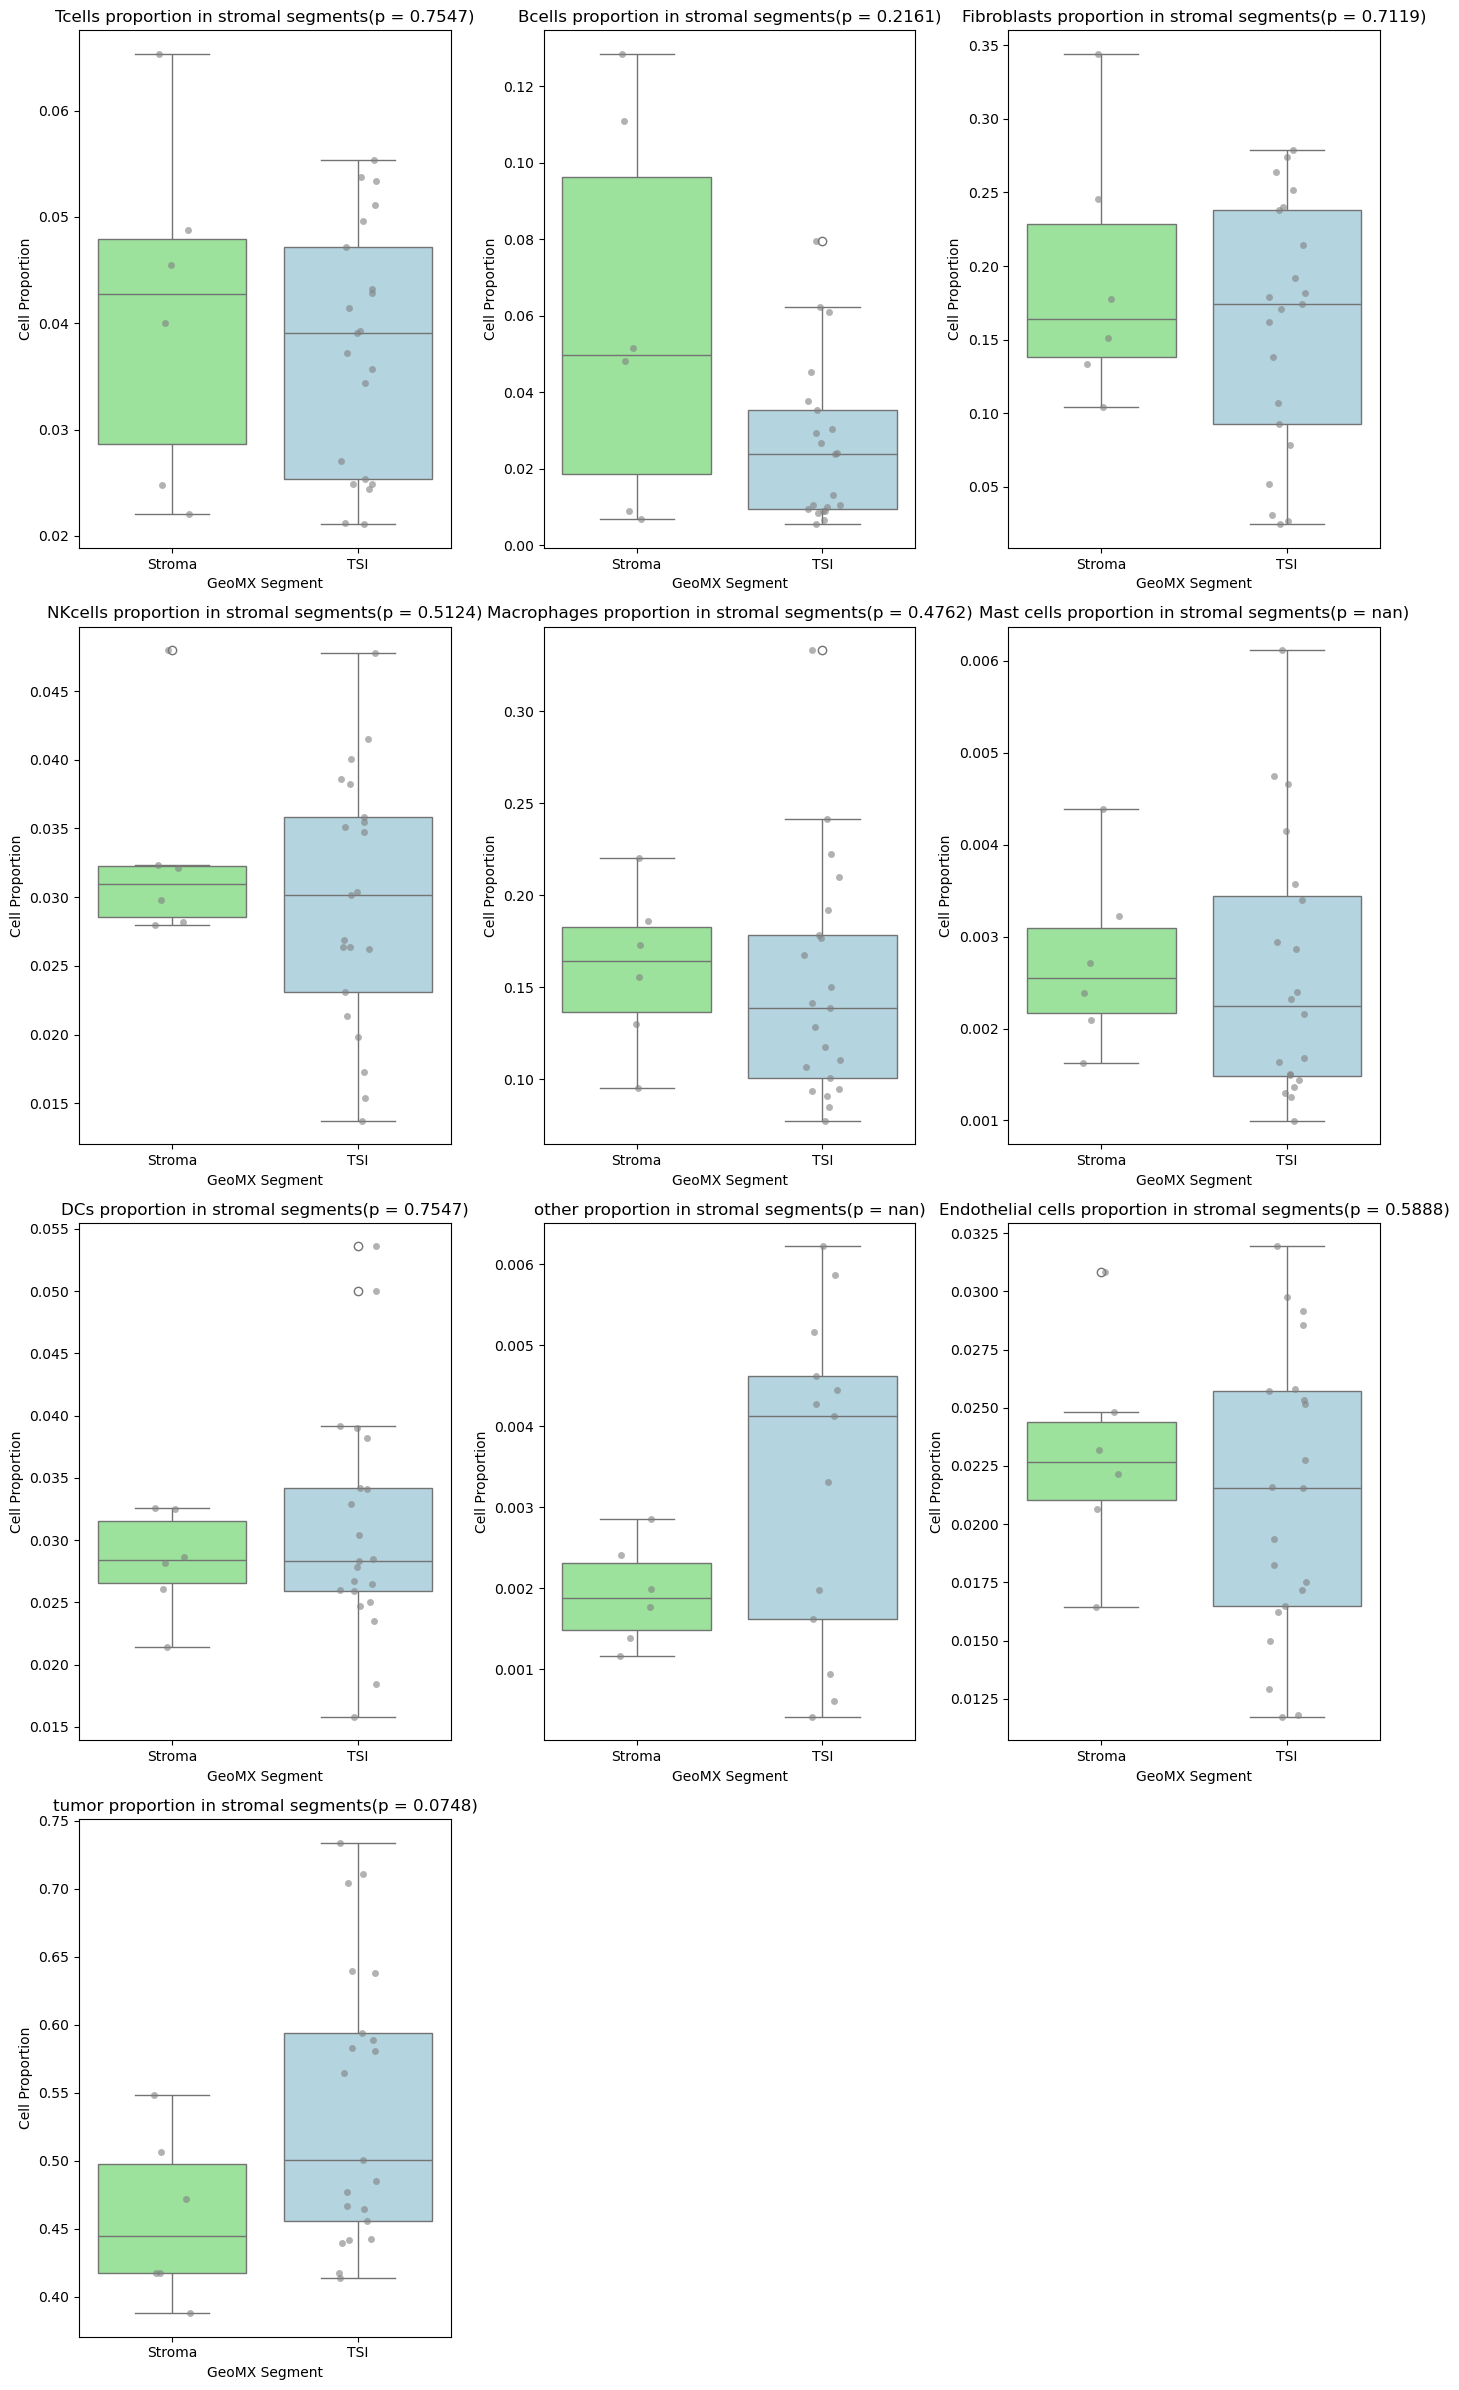

In [50]:
import math

num_plots = len(cell_types)
ncols = 3
nrows = math.ceil(num_plots / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, nrows * 6))
axes = axes.flatten()

for i, cell in enumerate(cell_types):
    combined = combined.reset_index(drop=True)
    ax = axes[i]

    # Extract data
    group_stroma = combined[combined["Segment"] == "Stroma"][cell]
    group_tsi = combined[combined["Segment"] == "TSI"][cell]

    # Mann-Whitney U test
    stat, p_value = mannwhitneyu(group_stroma, group_tsi, alternative='two-sided')

    # Plot
    sns.boxplot(x="Segment", y=cell, data=combined, ax=ax, palette=["lightgreen", "lightblue"])
    sns.stripplot(x="Segment", y=cell, data=combined, color='gray', alpha=0.6, jitter=True, ax=ax)

    # Label
    ax.set_title(f"{cell} proportion in stromal segments(p = {p_value:.4f})")
    ax.set_xlabel("GeoMX Segment")
    ax.set_ylabel("Cell Proportion")

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


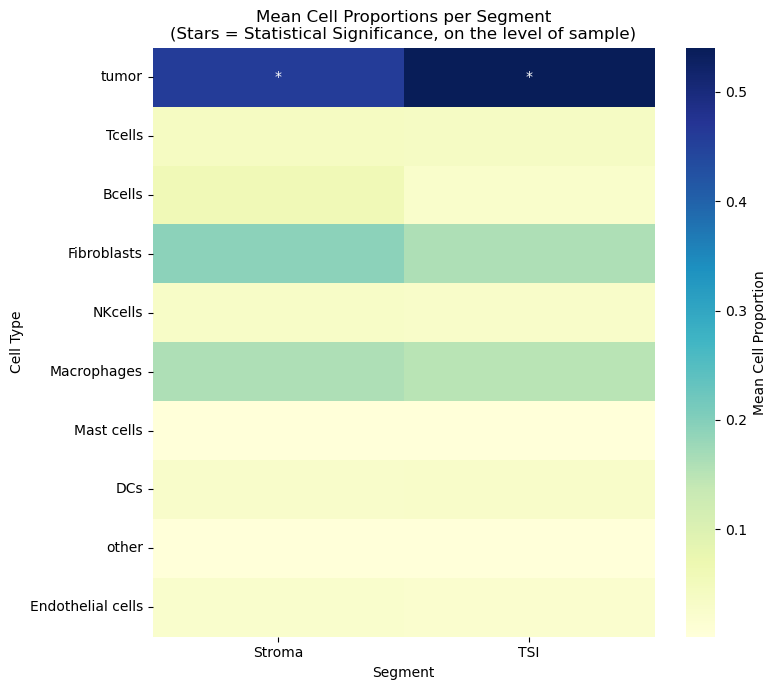

In [75]:

heatmap_data = []
significance_data = []

for cell in cell_types:
    group_stroma = combined[combined["Segment"] == "Stroma"][cell]
    group_tsi = combined[combined["Segment"] == "TSI"][cell]
    group_tsi = group_tsi.dropna()
    group_stroma = group_stroma.dropna()  # Ensure no NaN values for the Mann-Whitney U test
    mean_stroma = group_stroma.mean()
    mean_tsi = group_tsi.mean()

    # Mann-Whitney U test
    stat, p_value = mannwhitneyu(group_stroma, group_tsi, alternative='two-sided')

    # Significance stars
    if p_value < 0.01:
        stars = '***'
    elif p_value < 0.05:
        stars = '**'
    elif p_value < 0.1:
        stars = '*'
    else:
        stars = ''

    heatmap_data.append([mean_stroma, mean_tsi])
    significance_data.append([stars, stars])  # Optional: annotate both cells, or just one

# Create DataFrames
heatmap_df = pd.DataFrame(heatmap_data, columns=["Stroma", "TSI"], index=cell_types)
annotations_df = pd.DataFrame(significance_data, columns=["Stroma", "TSI"], index=cell_types)

# Plot heatmap
plt.figure(figsize=(8, len(cell_types) * 0.5 + 2))
sns.heatmap(heatmap_df, annot=annotations_df, fmt='', cmap="YlGnBu", cbar_kws={'label': 'Mean Cell Proportion'})

plt.title("Mean Cell Proportions per Segment\n(Stars = Statistical Significance, on the level of sample)")
plt.xlabel("Segment")
plt.ylabel("Cell Type")
plt.tight_layout()
plt.show()


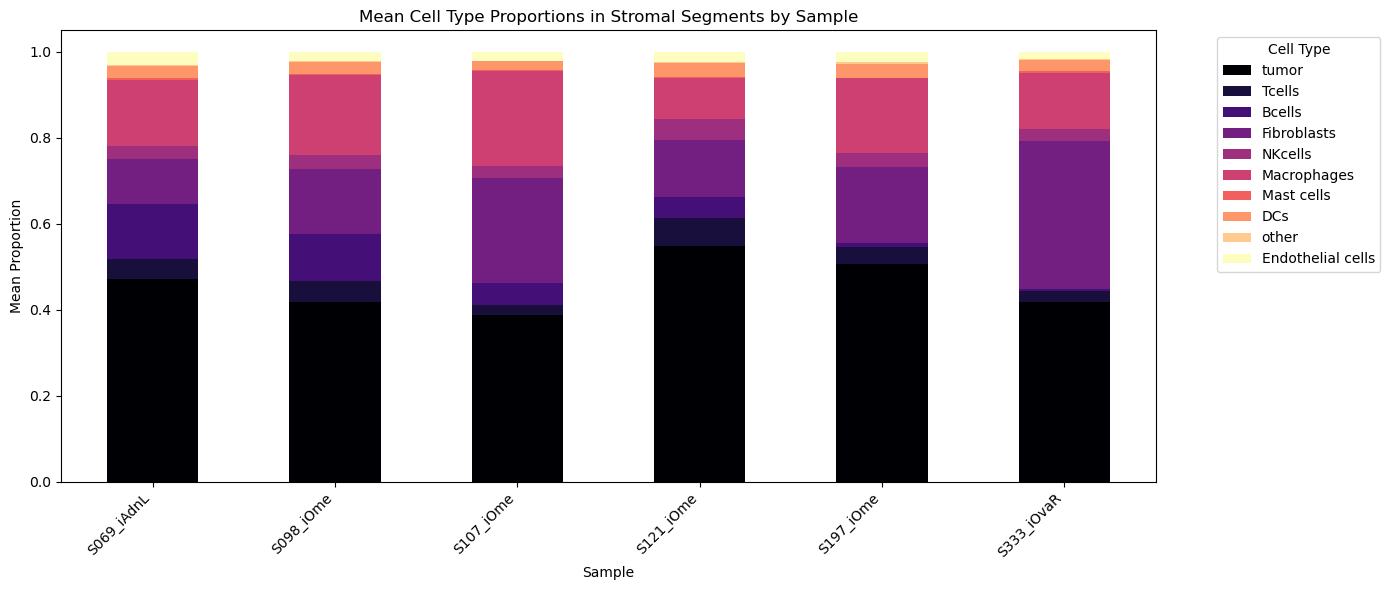

In [52]:

cell_types=["tumor","Tcells","Bcells",	"Fibroblasts", "NKcells", "Macrophages","Mast cells", "DCs", "other", "Endothelial cells"]
stroma_df = combined[combined["Segment"] == "Stroma"].copy()

# Set your relevant cell type columns # Adjust to your actual column names

# Group by Sample and calculate mean proportions
mean_props = stroma_df.groupby("Sample_y")[cell_types].mean()

# Normalize rows to sum to 1 (for stacked proportions)
mean_props = mean_props.div(mean_props.sum(axis=1), axis=0)

# Plotting
mean_props.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='magma')

plt.xlabel("Sample")
plt.ylabel("Mean Proportion")
plt.title("Mean Cell Type Proportions in Stromal Segments by Sample")
plt.xticks(rotation=45, ha='right')
plt.legend(title='Cell Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


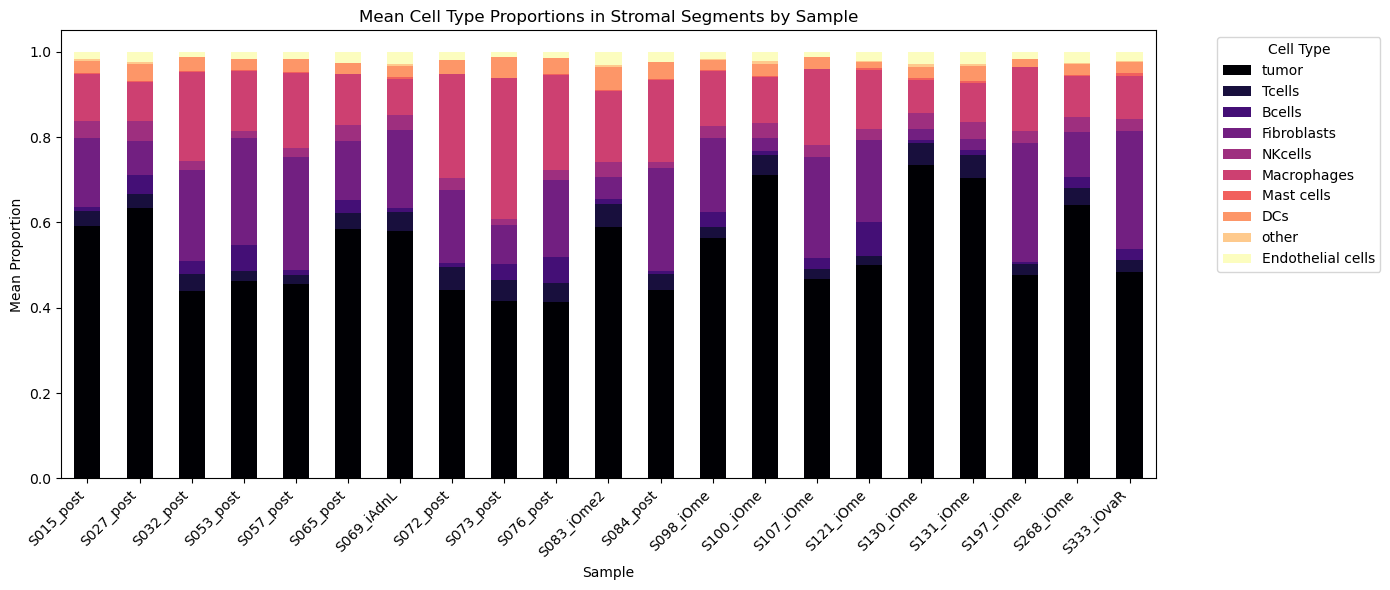

In [53]:
stroma_df = combined[combined["Segment"] == "TSI"].copy()

# Set your relevant cell type columns # Adjust to your actual column names

# Group by Sample and calculate mean proportions
mean_props = stroma_df.groupby("Sample_y")[cell_types].mean()

# Normalize rows to sum to 1 (for stacked proportions)
mean_props = mean_props.div(mean_props.sum(axis=1), axis=0)

# Plotting
mean_props.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='magma')

plt.xlabel("Sample")
plt.ylabel("Mean Proportion")
plt.title("Mean Cell Type Proportions in Stromal Segments by Sample")
plt.xticks(rotation=45, ha='right')
plt.legend(title='Cell Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

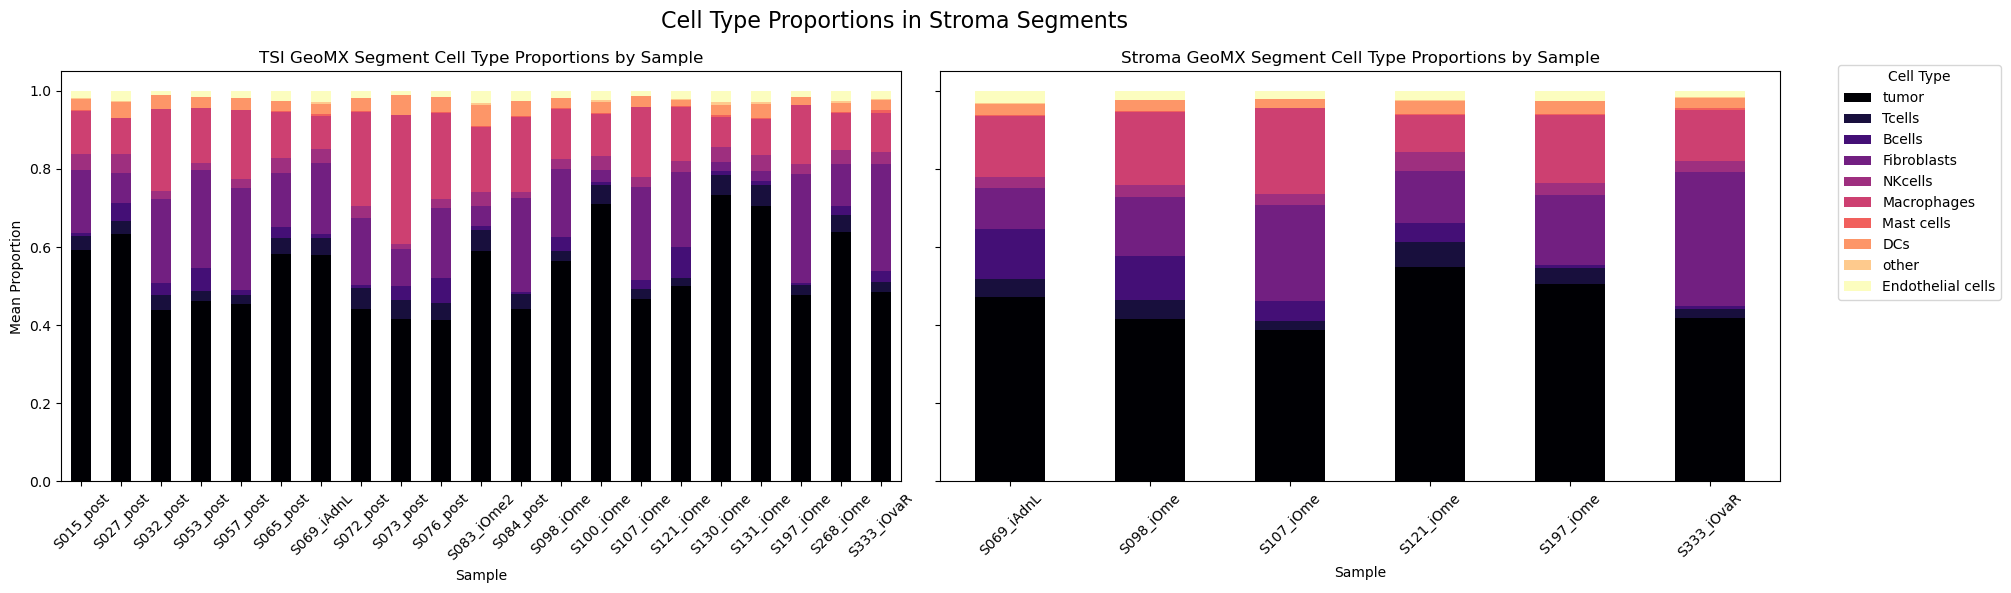

In [54]:
import matplotlib.pyplot as plt

# Cell types
cell_types = ["tumor", "Tcells", "Bcells", "Fibroblasts", "NKcells", "Macrophages", 
              "Mast cells", "DCs", "other", "Endothelial cells"]

# Filter and group by segment
tsi_df = combined[combined["Segment"] == "TSI"].copy()
stroma_df = combined[combined["Segment"] == "Stroma"].copy()

tsi_props = tsi_df.groupby("Sample_y")[cell_types].mean()
stroma_props = stroma_df.groupby("Sample_y")[cell_types].mean()

# Normalize for stacked proportions
tsi_props = tsi_props.div(tsi_props.sum(axis=1), axis=0)
stroma_props = stroma_props.div(stroma_props.sum(axis=1), axis=0)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

# Plot TSI
tsi_props.plot(kind='bar', stacked=True, ax=axes[0], colormap='magma',legend=False)
axes[0].set_title("TSI GeoMX Segment Cell Type Proportions by Sample")
axes[0].set_xlabel("Sample")
axes[0].set_ylabel("Mean Proportion")
axes[0].tick_params(axis='x', rotation=45)

# Plot Stroma
stroma_props.plot(kind='bar', stacked=True, ax=axes[1], colormap='magma',legend=False)
axes[1].set_title("Stroma GeoMX Segment Cell Type Proportions by Sample")
axes[1].set_xlabel("Sample")
axes[1].tick_params(axis='x', rotation=45)

# Shared legend
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, title="Cell Type", bbox_to_anchor=(1.02, 0.9), loc='upper left')

fig.suptitle("Cell Type Proportions in Stroma Segments", fontsize=16)


plt.tight_layout()
plt.show()


Cell abundance proportion on the DCC file level , box plots

In [56]:
fibr_gene_expression_cell_abundance=fibr_gene_expression_cell_abundance[fibr_gene_expression_cell_abundance["Segment_y"]=="stroma"]

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_4458/3605236164.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Segment_geomx", y=cell, data=fibr_gene_expression_cell_abundance, ax=ax, palette=["lightgreen", "lightblue"])
/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_4458/3605236164.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Segment_geomx", y=cell, data=fibr_gene_expression_cell_abundance, ax=ax, palette=["lightgreen", "lightblue"])
/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_4458/3605236164.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

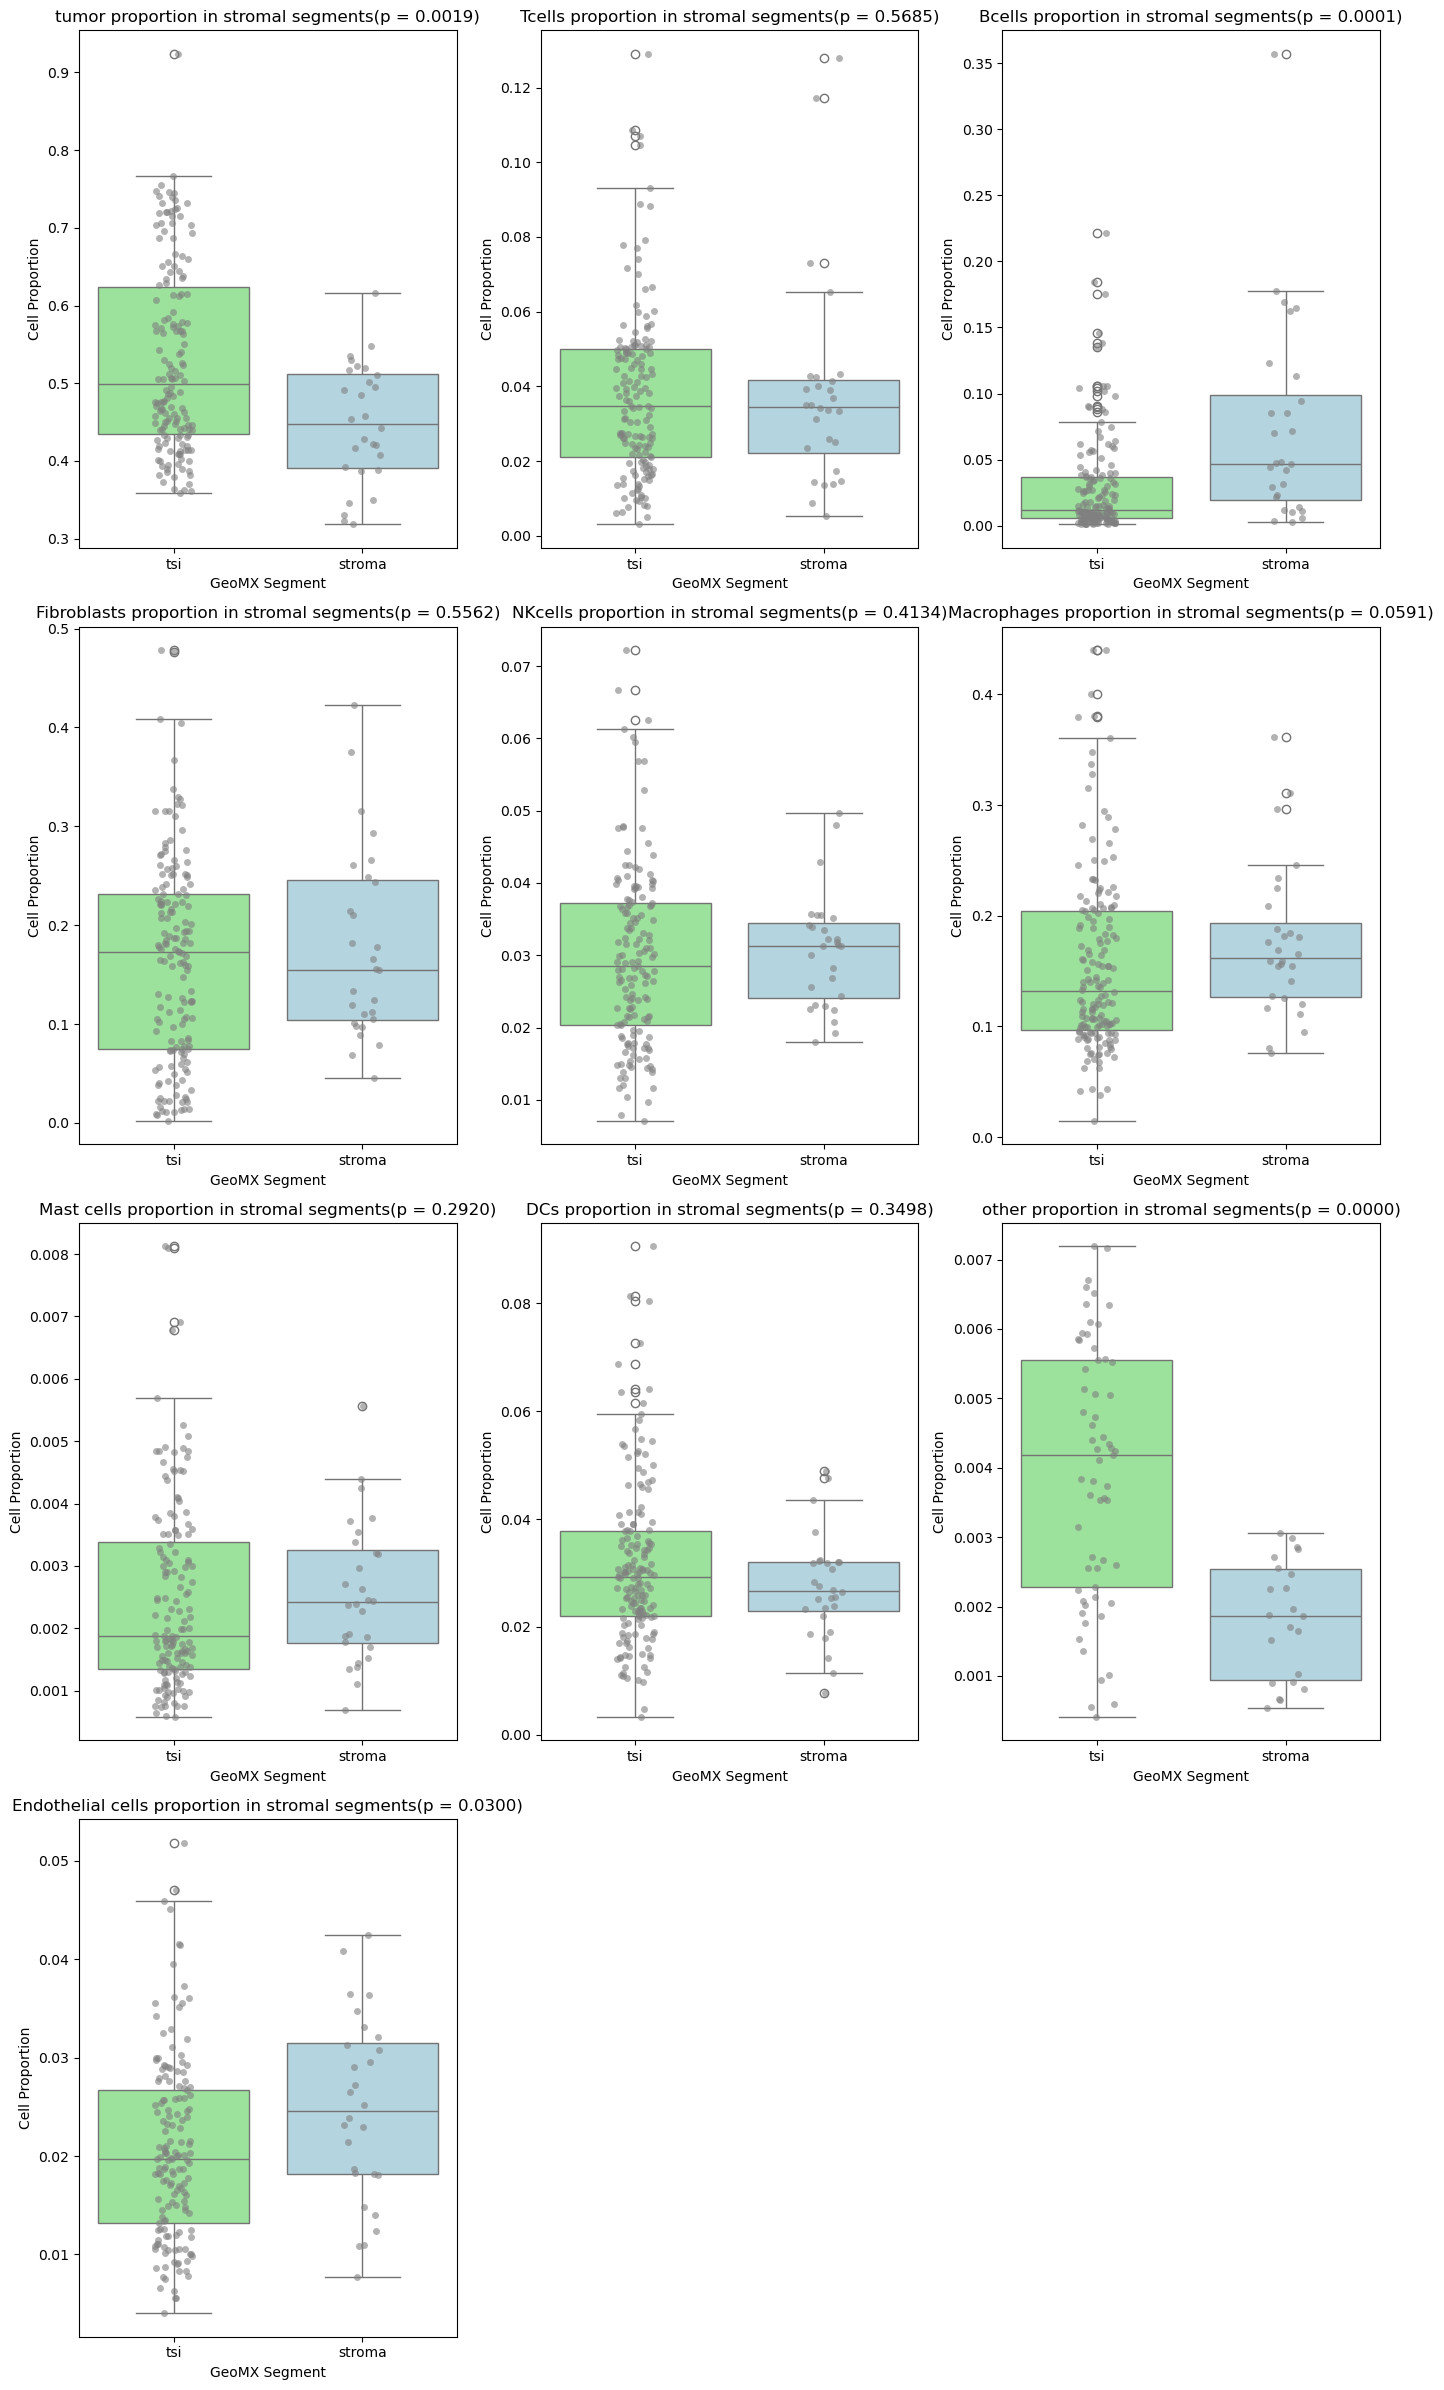

In [57]:
import math

num_plots = len(cell_types)
ncols = 3
nrows = math.ceil(num_plots / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, nrows * 6))
axes = axes.flatten()

for i, cell in enumerate(cell_types):
    combined = combined.reset_index(drop=True)
    ax = axes[i]

    # Extract data
    group_stroma = fibr_gene_expression_cell_abundance[fibr_gene_expression_cell_abundance["Segment_geomx"] == "stroma"][cell]
    group_tsi = fibr_gene_expression_cell_abundance[fibr_gene_expression_cell_abundance["Segment_geomx"] == "tsi" ][cell]
    group_stroma=group_stroma.dropna()
    group_tsi=group_tsi.dropna()

    # Mann-Whitney U test
    stat, p_value = mannwhitneyu(group_stroma, group_tsi, alternative='two-sided')

    # Plot
    sns.boxplot(x="Segment_geomx", y=cell, data=fibr_gene_expression_cell_abundance, ax=ax, palette=["lightgreen", "lightblue"])
    sns.stripplot(x="Segment_geomx", y=cell, data=fibr_gene_expression_cell_abundance, color='gray', alpha=0.6, jitter=True, ax=ax)

    # Label
    ax.set_title(f"{cell} proportion in stromal segments(p = {p_value:.4f})")
    ax.set_xlabel("GeoMX Segment")
    ax.set_ylabel("Cell Proportion")

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


1398.0 0.0019465139216926133
1983.0 0.5684608819610277
3201.0 0.00012277547600515406
2367.0 0.556247399308033
2351.0 0.41337552057900795
2708.0 0.05914044649929196
2333.0 0.29203710747352585
1966.0 0.34978591819906524
237.0 7.726023034820233e-06
2765.0 0.029989630568322427


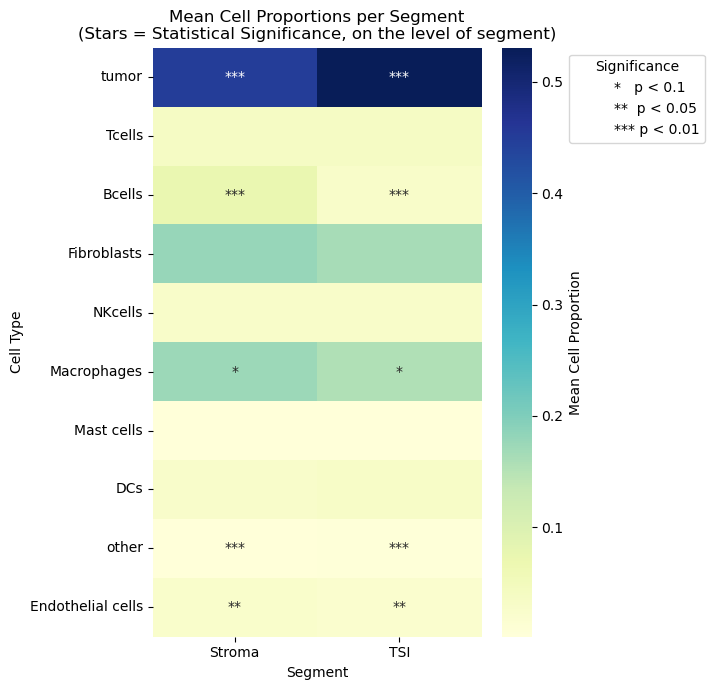

In [74]:

from matplotlib.patches import Patch
heatmap_data = []
significance_data = []

for cell in cell_types:
    group_stroma = fibr_gene_expression_cell_abundance[fibr_gene_expression_cell_abundance["Segment_geomx"] == "stroma"][cell]
    group_tsi = fibr_gene_expression_cell_abundance[fibr_gene_expression_cell_abundance["Segment_geomx"] == "tsi"][cell]
    group_stroma = group_stroma.dropna()
    group_tsi = group_tsi.dropna()  
    mean_stroma = group_stroma.mean()
    mean_tsi = group_tsi.mean()

    # Mann-Whitney U test
    stat, p_value = mannwhitneyu(group_stroma, group_tsi, alternative='two-sided')

    # Significance stars
    if p_value < 0.01:
        stars = '***'
    elif p_value < 0.05:
        stars = '**'
    elif p_value < 0.1:
        stars = '*'
    else:
        stars = ''
    print(stat,p_value)
    heatmap_data.append([mean_stroma, mean_tsi])
    significance_data.append([stars, stars])  # Optional: annotate both cells, or just one

# Create DataFrames
heatmap_df = pd.DataFrame(heatmap_data, columns=["Stroma", "TSI"], index=cell_types)
annotations_df = pd.DataFrame(significance_data, columns=["Stroma", "TSI"], index=cell_types)

# Plot heatmap
plt.figure(figsize=(8, len(cell_types) * 0.5 + 2))
sns.heatmap(heatmap_df, annot=annotations_df, fmt='', cmap="YlGnBu", cbar_kws={'label': 'Mean Cell Proportion'})

legend_elements = [
    Patch(facecolor='none', edgecolor='none', label='*   p < 0.1'),
    Patch(facecolor='none', edgecolor='none', label='**  p < 0.05'),
    Patch(facecolor='none', edgecolor='none', label='*** p < 0.01'),
]

plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.7, 1), frameon=True, title='Significance')

plt.title("Mean Cell Proportions per Segment\n(Stars = Statistical Significance, on the level of segment)")
plt.xlabel("Segment")
plt.ylabel("Cell Type")
plt.tight_layout()
plt.show()

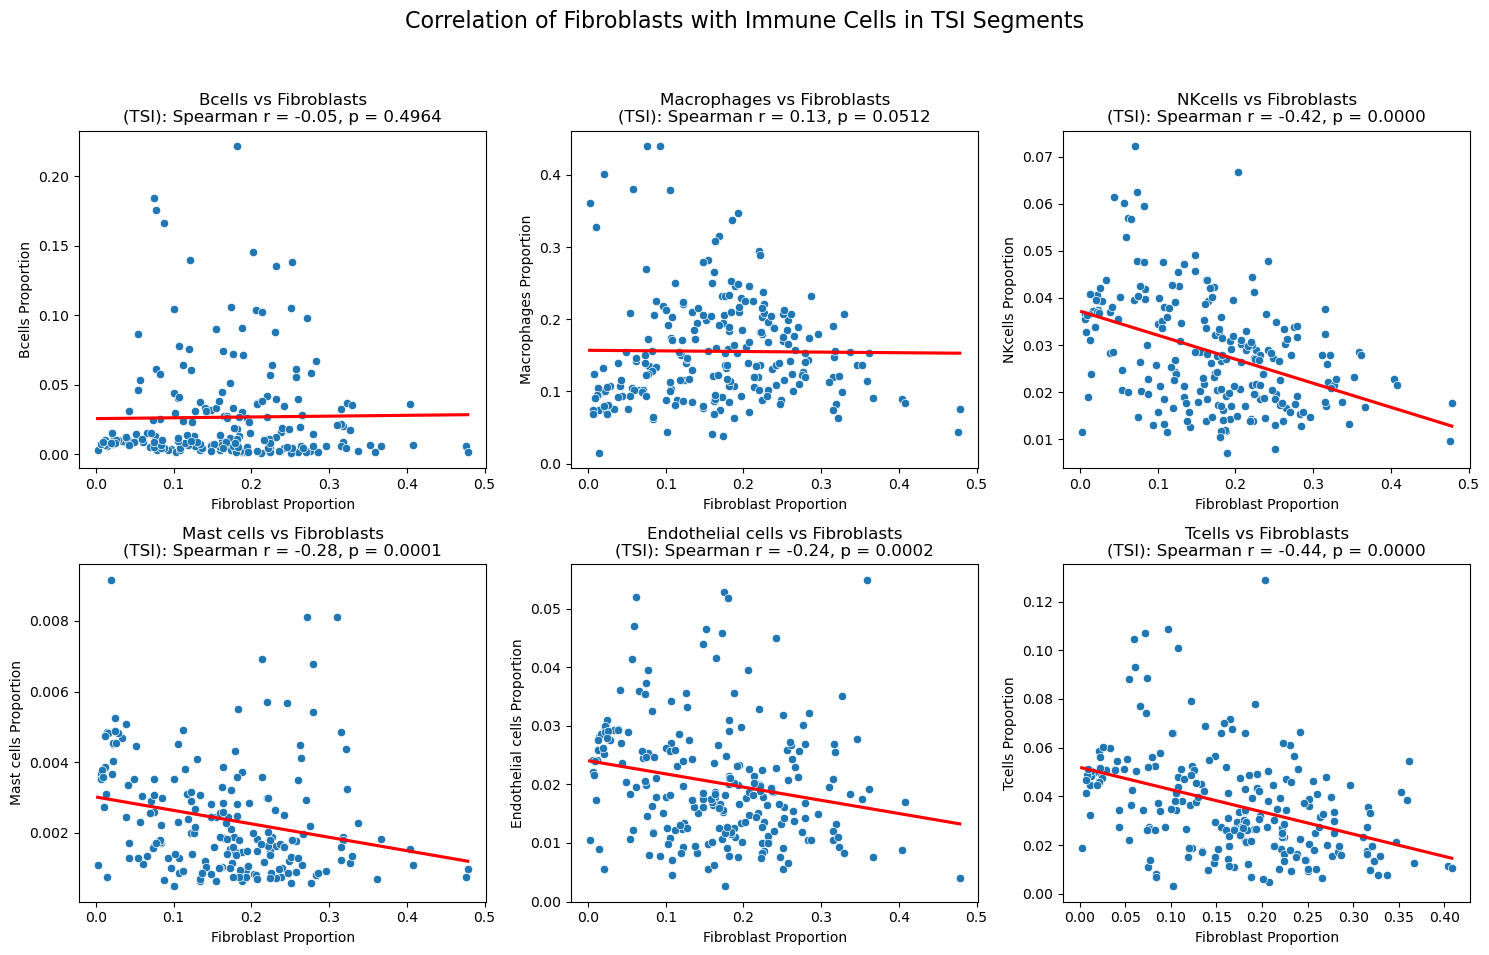

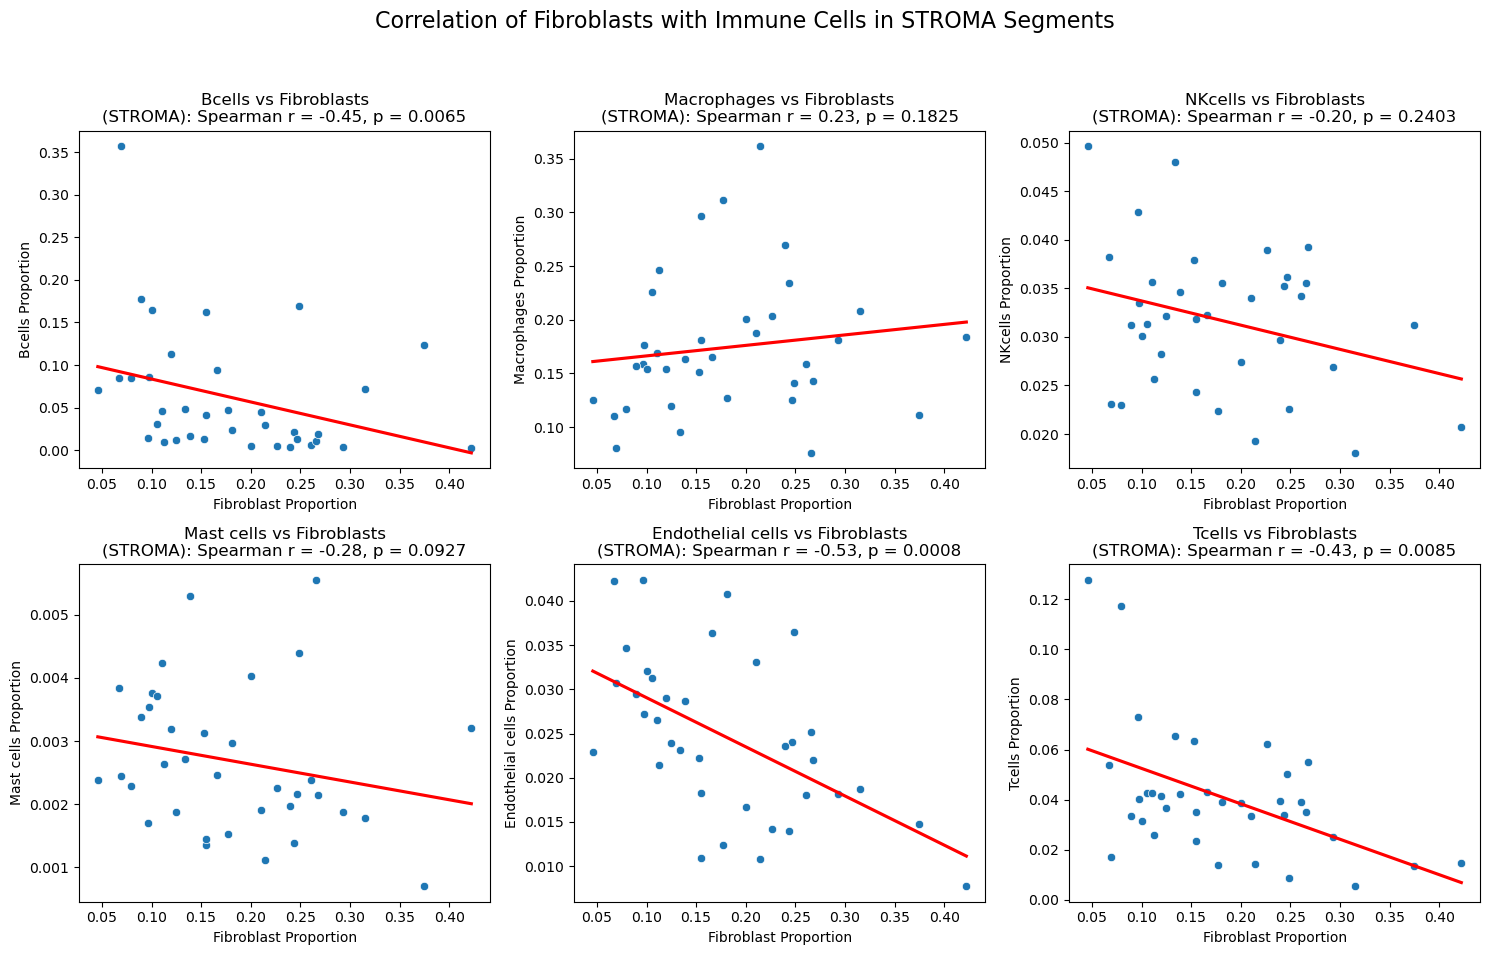

In [229]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import math

# Define your variables
fibroblast_col = "Fibroblasts"  # Adjust if named differently
immune_cells = ["Bcells", "Macrophages", "NKcells", "Mast cells", "Endothelial cells","Tcells"]  # Update names if needed

# Loop through 'tsi' and 'stroma'
for segment in ["tsi", "stroma"]:
    subset = df_cell_abundance_stroma[df_cell_abundance_stroma["Segment_geomx"] == segment]

    num_plots = len(immune_cells)
    ncols = 3
    nrows = math.ceil(num_plots / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 5))
    axes = axes.flatten()

    for i, immune_cell in enumerate(immune_cells):
        ax = axes[i]
        
        x = subset[fibroblast_col]
        y = subset[immune_cell]

        # Drop NaNs
        mask = x.notna() & y.notna()
        x = x[mask]
        y = y[mask]

        # Spearman correlation
        rho, p = spearmanr(x, y)

        # Plot
        sns.scatterplot(x=x, y=y, ax=ax)
        sns.regplot(x=x, y=y, ax=ax, scatter=False, color='red', ci=None)

        ax.set_title(f"{immune_cell} vs Fibroblasts\n({segment.upper()}): Spearman r = {rho:.2f}, p = {p:.4f}")
        ax.set_xlabel("Fibroblast Proportion")
        ax.set_ylabel(f"{immune_cell} Proportion")

    # Remove empty axes
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f"Correlation of Fibroblasts with Immune Cells in {segment.upper()} Segments", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


In [224]:
df_cell_abundance_stroma_post = df_cell_abundance[
    (df_cell_abundance["Segment"] == "stroma") & 
    (df_cell_abundance["NACT_status"] == "post")
]

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/73917004.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Segment_geomx", y=cell, data=df_cell_abundance_stroma_post, ax=ax, palette=["lightgreen", "lightblue"])
/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/73917004.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Segment_geomx", y=cell, data=df_cell_abundance_stroma_post, ax=ax, palette=["lightgreen", "lightblue"])
/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/73917004.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `le

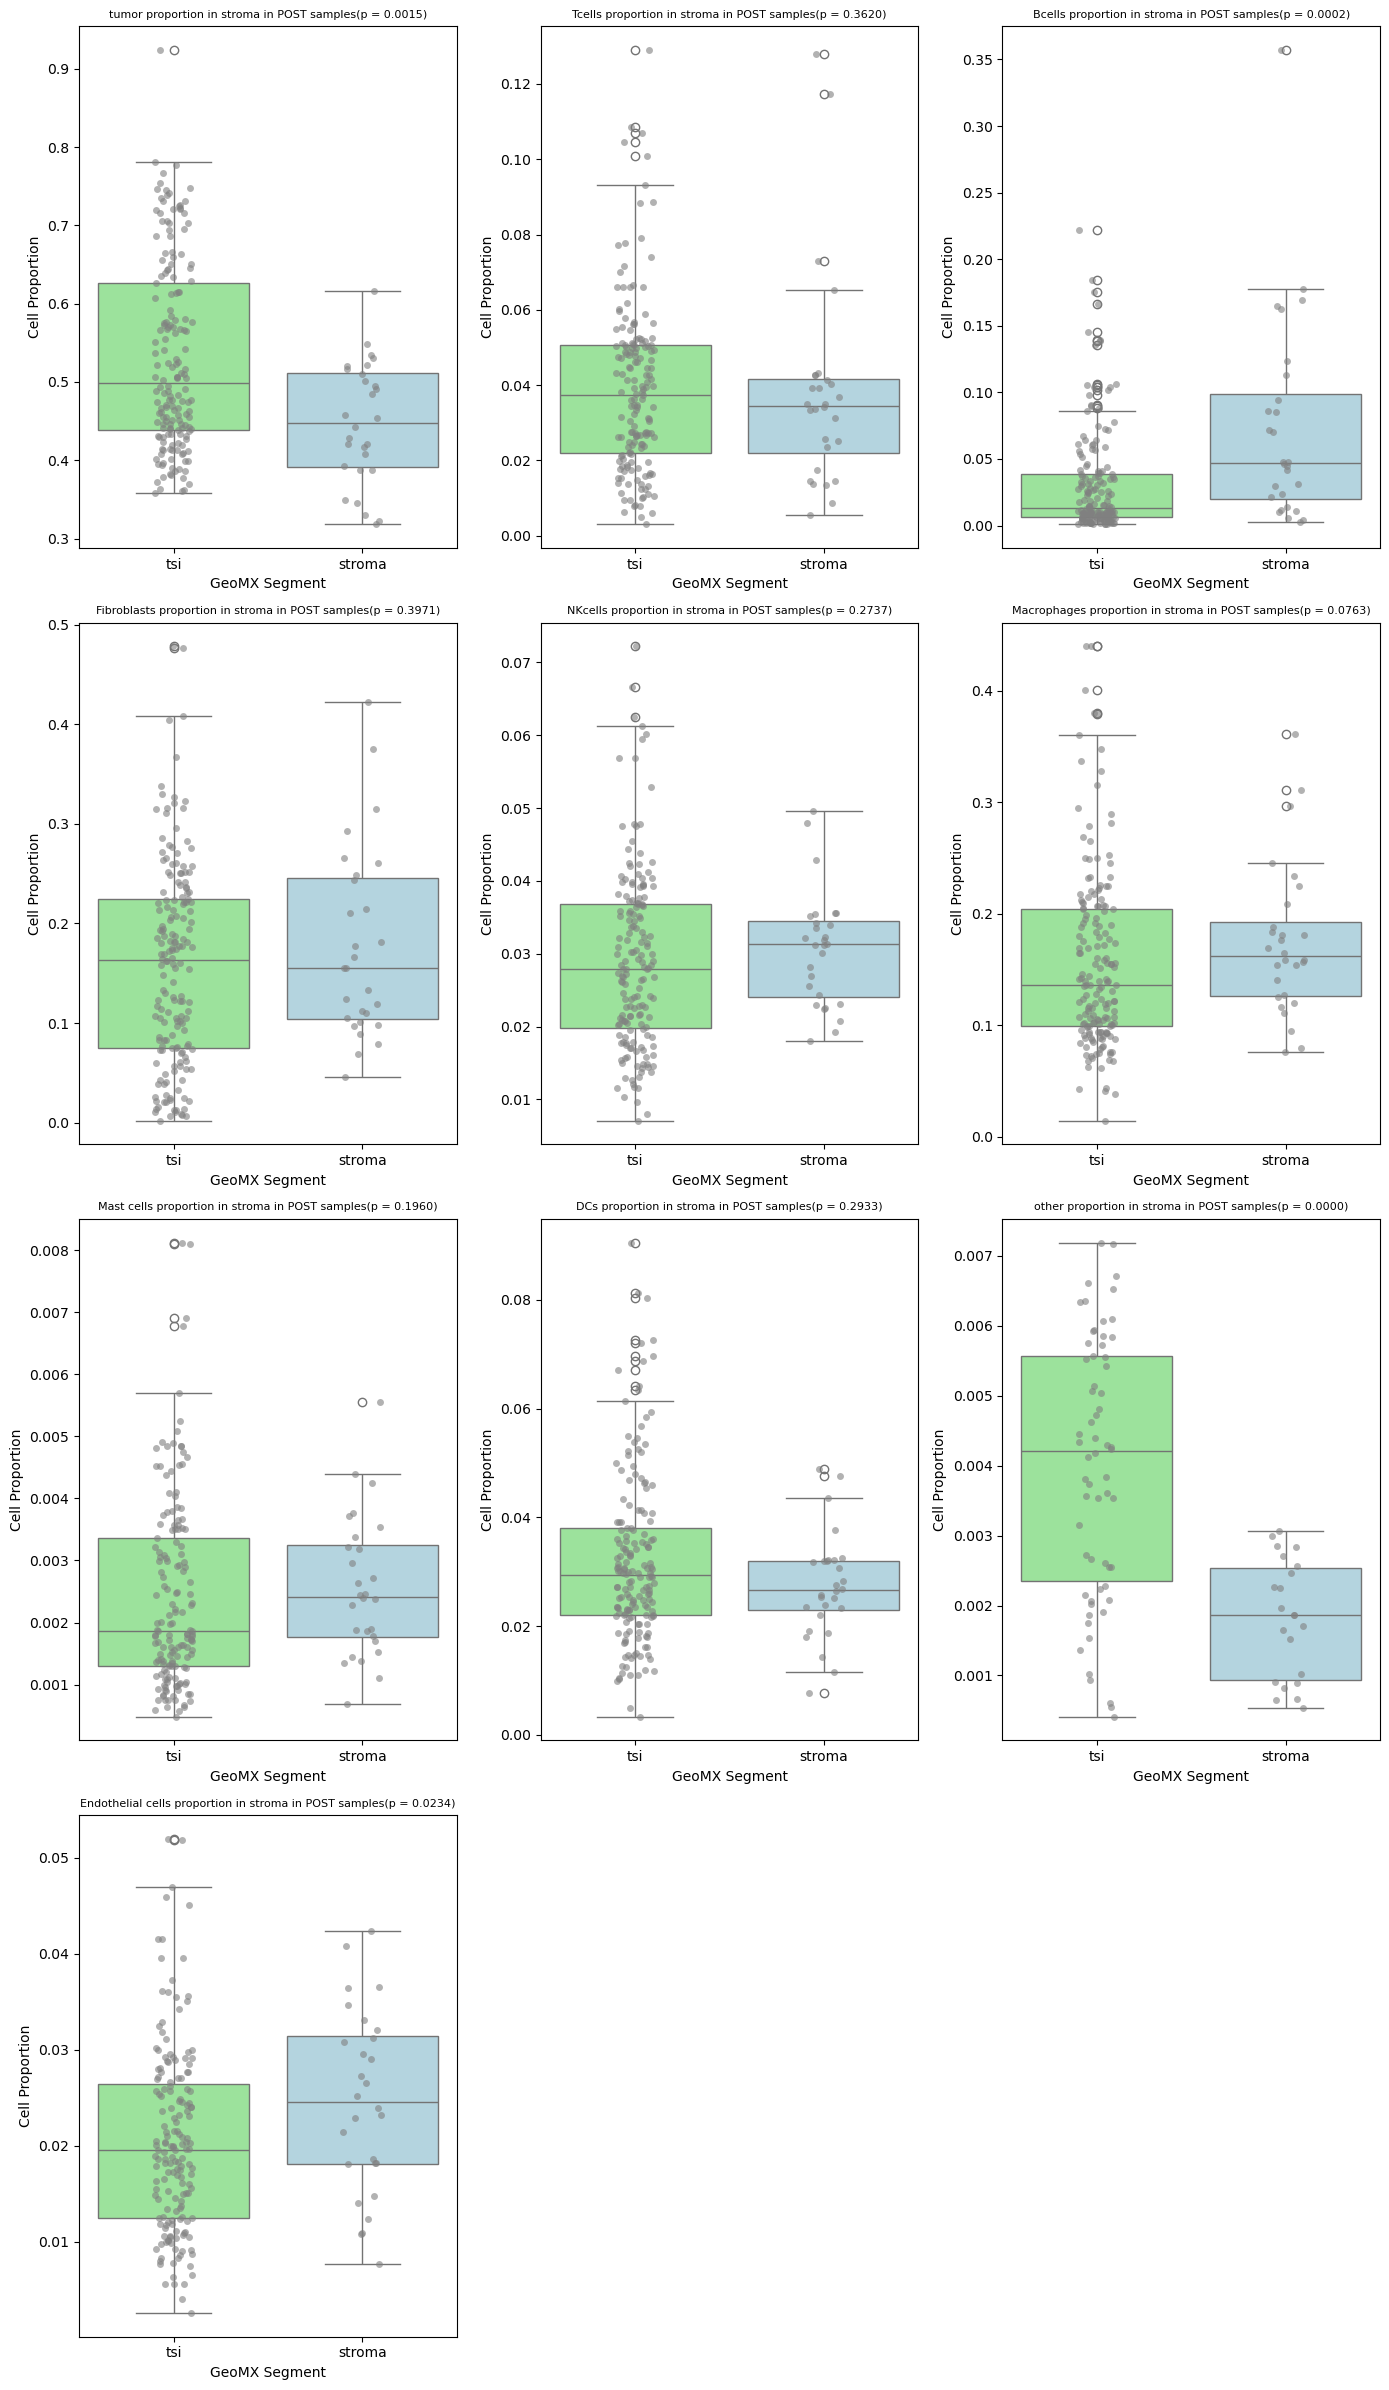

In [225]:
import math

num_plots = len(cell_types)
ncols = 3
nrows = math.ceil(num_plots / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, nrows * 6))
axes = axes.flatten()

for i, cell in enumerate(cell_types):
    combined = combined.reset_index(drop=True)
    ax = axes[i]

    # Extract data
    group_stroma = df_cell_abundance_stroma_post[df_cell_abundance_stroma_post["Segment_geomx"] == "stroma"][cell]
    group_tsi = df_cell_abundance_stroma_post[df_cell_abundance_stroma_post["Segment_geomx"] == "tsi" ][cell]
    group_stroma=group_stroma.dropna()
    group_tsi=group_tsi.dropna()

    # Mann-Whitney U test
    stat, p_value = mannwhitneyu(group_stroma, group_tsi, alternative='two-sided')

    # Plot
    sns.boxplot(x="Segment_geomx", y=cell, data=df_cell_abundance_stroma_post, ax=ax, palette=["lightgreen", "lightblue"])
    sns.stripplot(x="Segment_geomx", y=cell, data=df_cell_abundance_stroma_post, color='gray', alpha=0.6, jitter=True, ax=ax)

    # Label
    ax.set_title(f"{cell} proportion in stroma in POST samples(p = {p_value:.4f})",size=8)
    ax.set_xlabel("GeoMX Segment")
    ax.set_ylabel("Cell Proportion")

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

DEG expression analysis adopted from Ada

In [76]:

import pandas as pd
from scipy.stats import ttest_ind  # Add this import statement
from statsmodels.stats.multitest import multipletests
def volcano_analysis_with_comparison(data, group_column, comparison_labels, gene_columns):
    """
    Perform volcano analysis on RNAseq data for specified group comparisons.

    Parameters:
    - data (DataFrame): DataFrame containing RNAseq data.
    - group_column (str): Name of the column containing group labels.
    - comparison_labels (list of tuples): List of tuples specifying group label pairs for comparison.
    - gene_columns (slice): Slice object representing the range of columns containing gene information.

    Returns:
    - DataFrame: DataFrame with columns for fold change, p-value, q-value, -log10(p-value), and -log10(q-value)
                 for each specified group comparison.
    """
    result_df = pd.DataFrame()
    #gene_columns = geomx_data.columns
    print(gene_columns)
    for comparison in comparison_labels:
        group1, group2 = comparison
        print(group1, group2)
        # Calculate fold change
        group1_data = data[data[group_column] == group1].loc[:, gene_columns]
        group2_data = data[data[group_column] == group2].loc[:, gene_columns]
        avg_group1 = group1_data.mean()
        avg_group2 = group2_data.mean()
        fold_change = np.log2((group2_data.mean() + 1e-6) / (group1_data.mean() + 1e-6))
        # Calculate log2 fold change (log2 of fold-change)
        fold_change.name = f'fold-change_{group2}_over_{group1}'

        # Calculate p-value
        pvals = []
        for name in group1_data.columns:
            group1_val = group1_data[name]
            group2_val = group2_data[name]
            pvals.append(ttest_ind(group1_val, group2_val)[1])
        # Calculate q-value
        q_values = multipletests(pvals, method='fdr_bh')[1]

        # -log10 p-value
        log10pvals = [-np.log10(value) for value in pvals]

        # -log10 q-value
        log10qvals = [-np.log10(value) for value in q_values]

        # Add fold change, p-value, q-value, -log10(p-value), and -log10(q-value) to the result DataFrame
        result_df[f'fold-change'] = fold_change
        result_df[f'p-value'] = pvals
        result_df[f'q-value'] = q_values
        result_df[f'-log10_pvalue'] = log10pvals
        result_df[f'-log10_qvalue'] = log10qvals

    return result_df

In [77]:
fibr_gene_expression_cell_abundance.head(3)

,dcc_filename,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,HES4,ISG15,AGRN,RNF223,...,Segment_y,Sample_y,NACT_status_y,Annotation_cell_y,Roi.1,Segment_geomx,Patient_y,Site_y,PFS_HL_group,OS_HL_group
0,DSP-1001660016604-A-A02.dcc,1.395991,1.907436,1.506498,1.700645,-0.045271,2.111774,4.080095,1.987522,-0.088093,...,stroma,S130_iOme,post,CD8_Iba1,NaN,tsi,S130,Omentum,Low,Low
2,DSP-1001660016604-A-A04.dcc,1.224783,1.724003,1.333149,1.528053,-0.045955,1.932914,5.415247,1.805880,-0.088144,...,stroma,S130_iOme,post,CD8_CD11_Iba1,NaN,tsi,S130,Omentum,Low,Low
6,DSP-1001660016604-A-A08.dcc,1.452303,1.272854,0.866100,1.059784,-0.044865,1.474579,3.203162,1.351901,-0.088062,...,stroma,S130_iOme,post,CD4_CD11,NaN,tsi,S130,Omentum,Low,Low


In [78]:
fibr_gene_expression_cell_abundance_POST= fibr_gene_expression_cell_abundance[fibr_gene_expression_cell_abundance["NACT_status_y"] == "post"]
fibr_gene_expression_cell_abundance_POST_stroma= fibr_gene_expression_cell_abundance_POST[fibr_gene_expression_cell_abundance_POST["Segment_y"] == "stroma"]

In [79]:
fibr_gene_expression_cell_abundance_POST_stroma.head(3)

,dcc_filename,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,HES4,ISG15,AGRN,RNF223,...,Segment_y,Sample_y,NACT_status_y,Annotation_cell_y,Roi.1,Segment_geomx,Patient_y,Site_y,PFS_HL_group,OS_HL_group
0,DSP-1001660016604-A-A02.dcc,1.395991,1.907436,1.506498,1.700645,-0.045271,2.111774,4.080095,1.987522,-0.088093,...,stroma,S130_iOme,post,CD8_Iba1,NaN,tsi,S130,Omentum,Low,Low
2,DSP-1001660016604-A-A04.dcc,1.224783,1.724003,1.333149,1.528053,-0.045955,1.932914,5.415247,1.805880,-0.088144,...,stroma,S130_iOme,post,CD8_CD11_Iba1,NaN,tsi,S130,Omentum,Low,Low
6,DSP-1001660016604-A-A08.dcc,1.452303,1.272854,0.866100,1.059784,-0.044865,1.474579,3.203162,1.351901,-0.088062,...,stroma,S130_iOme,post,CD4_CD11,NaN,tsi,S130,Omentum,Low,Low


In [162]:
geomx_data= pd.read_csv("//Volumes/h30492/farkkilab2/4_CellCycle_Nika/geomx/Data/Ada_transformed_data/geomx_count_data.csv")

In [163]:
geomx_data.drop(columns=["RCN1","RCN2","RCN3"], inplace=True)

In [176]:
geomx_data = geomx_data[geomx_data.columns.intersection(fibr_gene_expression_cell_abundance_POST_stroma.columns)]

In [179]:
df_results = volcano_analysis_with_comparison(fibr_gene_expression_cell_abundance_POST_stroma, group_column='Segment_geomx', comparison_labels=[("stroma", "tsi")], gene_columns=geomx_data.columns)

Index(['A2M', 'NAT2', 'ACADM', 'ACADS', 'ACAT1', 'ACVRL1', 'PSEN1', 'ADA',
       'SGCA', 'ADRB2',
       ...
       'PRKCG', 'TNFSF18', 'CCL23', 'WNT6', 'GLI1', 'NDUFA3', 'HAMP', 'ADH1B',
       'CCL3', 'CST2'],
      dtype='object', length=14645)
stroma tsi


/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [80]:

# Prepare data tsi
df_plot = df_results.copy()
df_plot = df_plot.reset_index()
# Thresholds
pval_thresh = 0.01
fc_thresh = 1 # |Log2-FC| > 1

# Significance labeling
# Create boolean masks for both conditions
pval_condition = df_plot['-log10_qvalue'] > -np.log10(pval_thresh)
fc_condition = df_plot['fold-change'].abs() > fc_thresh

# Apply the AND condition to both
df_plot['Significant'] = pval_condition & fc_condition

# Plot
plt.figure(figsize=(15, 7))
sns.scatterplot(
    data=df_plot,
    x='fold-change',
    y='-log10_qvalue',
    s=10,
    hue='Significant',
    palette={True: '#FF6666', False: '#BDBDBD'}

)

# Annotations for top hits (optional)
top_hits = df_plot[df_plot['Significant']].sort_values('-log10_qvalue', ascending=False)
top_hits2 = df_plot.sort_values('-log10_qvalue', ascending=False)
for index, row in top_hits.iterrows():
    plt.text(row['fold-change'], row['-log10_qvalue'], row["index"], fontsize=6,
             ha='right' if row['fold-change'] < 0 else 'left', va='center')

# Reference lines
plt.axvline(x=fc_thresh, color='black', linestyle='--', linewidth=1)
plt.axvline(x=-fc_thresh, color='black', linestyle='--', linewidth=1)
plt.axhline(y=-np.log10(pval_thresh), color='black', linestyle='--', linewidth=1)

# Labels
plt.title('Volcano Plot: Fibroblast gene expression in TSI segments vs Stroma segments ')
plt.xlabel('Log2 fold-change')
plt.ylabel('-log10_pvalue')
plt.tight_layout()
plt.legend(title='Significant')
plt.show()

#print(row["gene_name"].head(5))

NameError: name 'df_results' is not defined

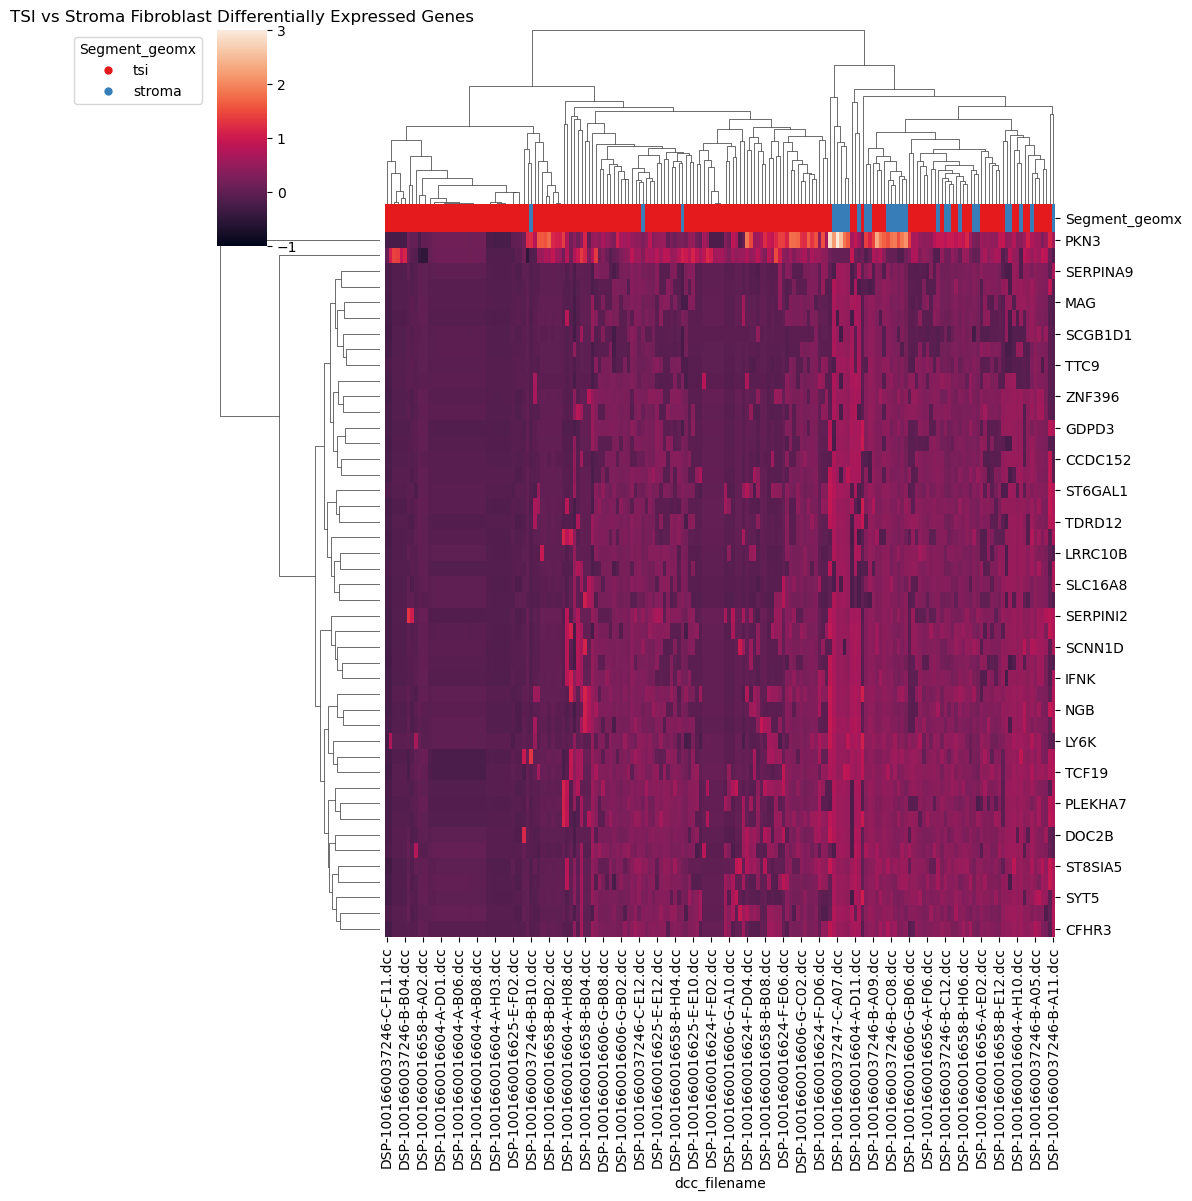

In [187]:
tsi_stroma_fibroblast_differential_genes = top_hits["index"]

# 1. Extract relevant gene expression data for the top hits (rows)
# Filter the expression data for the genes in 'cell_cycle_arrest_dormancy_genes'
merged_metadata = fibr_gene_expression_cell_abundance_POST_stroma.set_index('dcc_filename')
data_to_plot = merged_metadata[tsi_stroma_fibroblast_differential_genes]

# 2. Merge the metadata (geomx_data_meta_post) with expression data (geomx_data_post)
# Assuming 'Cellcycle_annot' column is present in merged_metadata
var = "Segment_geomx"  # Column name in merged_metadata to use for color mapping

# Create a color map based on 'Cellcycle_annot' values (assuming it's categorical)
cellcycle_colors = sns.color_palette("Set1", len(merged_metadata[var].unique()))
cellcycle_color_map = {val: cellcycle_colors[i] for i, val in enumerate(merged_metadata[var].unique())}

# Map the 'Cellcycle_annot' values to corresponding colors
row_colors = merged_metadata[var].map(cellcycle_color_map)

# 3. Plot the clustermap with annotations for rows (using 'Cellcycle_annot' for color mapping)
g = sns.clustermap(
    data_to_plot.T,  # Transpose the data to have genes as rows and samples as columns
    col_colors=row_colors,  # Add color mapping based on 'Cellcycle_annot'
    method="complete",  # Clustering method
    vmin=-1, vmax=3,  # Adjust these values based on your data range
    figsize=(10, 12)
)

# Optional: Add a title
plt.title("TSI vs Stroma Fibroblast Differentially Expressed Genes")

# Add a color bar legend to show what each color represents
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=7) for color in cellcycle_colors]
labels = list(cellcycle_color_map.keys())
plt.legend(handles=handles, labels=labels, title=var, bbox_to_anchor=(-3, 1), loc='upper left')

# Show the plot
plt.show()


In [188]:
merged_metadata

,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,HES4,ISG15,AGRN,RNF223,C1orf159,...,Segment_y,Sample_y,NACT_status_y,Annotation_cell_y,Roi.1,Segment_geomx,Patient_y,Site_y,PFS_HL_group,OS_HL_group
dcc_filename,,,,,,,,,,,,,,,,,,,,,
DSP-1001660016604-A-A02.dcc,1.395991,1.907436,1.506498,1.700645,-0.045271,2.111774,4.080095,1.987522,-0.088093,1.751489,...,stroma,S130_iOme,post,CD8_Iba1,NaN,tsi,S130,Omentum,Low,Low
DSP-1001660016604-A-A04.dcc,1.224783,1.724003,1.333149,1.528053,-0.045955,1.932914,5.415247,1.805880,-0.088144,1.578072,...,stroma,S130_iOme,post,CD8_CD11_Iba1,NaN,tsi,S130,Omentum,Low,Low
DSP-1001660016604-A-A08.dcc,1.452303,1.272854,0.866100,1.059784,-0.044865,1.474579,3.203162,1.351901,-0.088062,1.111117,...,stroma,S130_iOme,post,CD4_CD11,NaN,tsi,S130,Omentum,Low,Low
DSP-1001660016604-A-B02.dcc,1.466822,1.287681,1.579042,1.072317,-0.044713,2.188696,4.682901,1.366348,-0.088051,1.123834,...,stroma,S130_iOme,post,CD4_CD8_CD11,NaN,tsi,S130,Omentum,Low,Low
DSP-1001660016604-A-B06.dcc,1.693546,1.483212,1.075533,1.269143,-0.044801,2.414491,3.957813,1.562093,-0.088057,1.320554,...,stroma,S130_iOme,post,CD8_CD11_Iba1,NaN,tsi,S130,Omentum,Low,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DSP-1001660037247-C-A08.dcc,1.192934,1.194114,0.903114,0.707015,-0.193744,1.625835,2.452933,1.106361,-0.090014,0.940052,...,stroma,S069_iAdnL,post,CD4_CD8_CD11_Iba1,NaN,stroma,S069,Adnex,Low,Low
DSP-1001660037247-C-A09.dcc,1.090003,1.261863,1.259763,0.892262,0.321726,2.083266,2.472857,1.093538,-0.090010,0.689869,...,stroma,S069_iAdnL,post,CD4_CD8_CD11_Iba1,NaN,stroma,S069,Adnex,Low,Low
DSP-1001660037247-C-A10.dcc,0.603934,1.021494,1.019268,0.822956,-0.193868,1.778039,2.210968,1.222145,-0.090011,0.639584,...,stroma,S069_iAdnL,post,CD8_CD11_Iba1,NaN,stroma,S069,Adnex,Low,Low


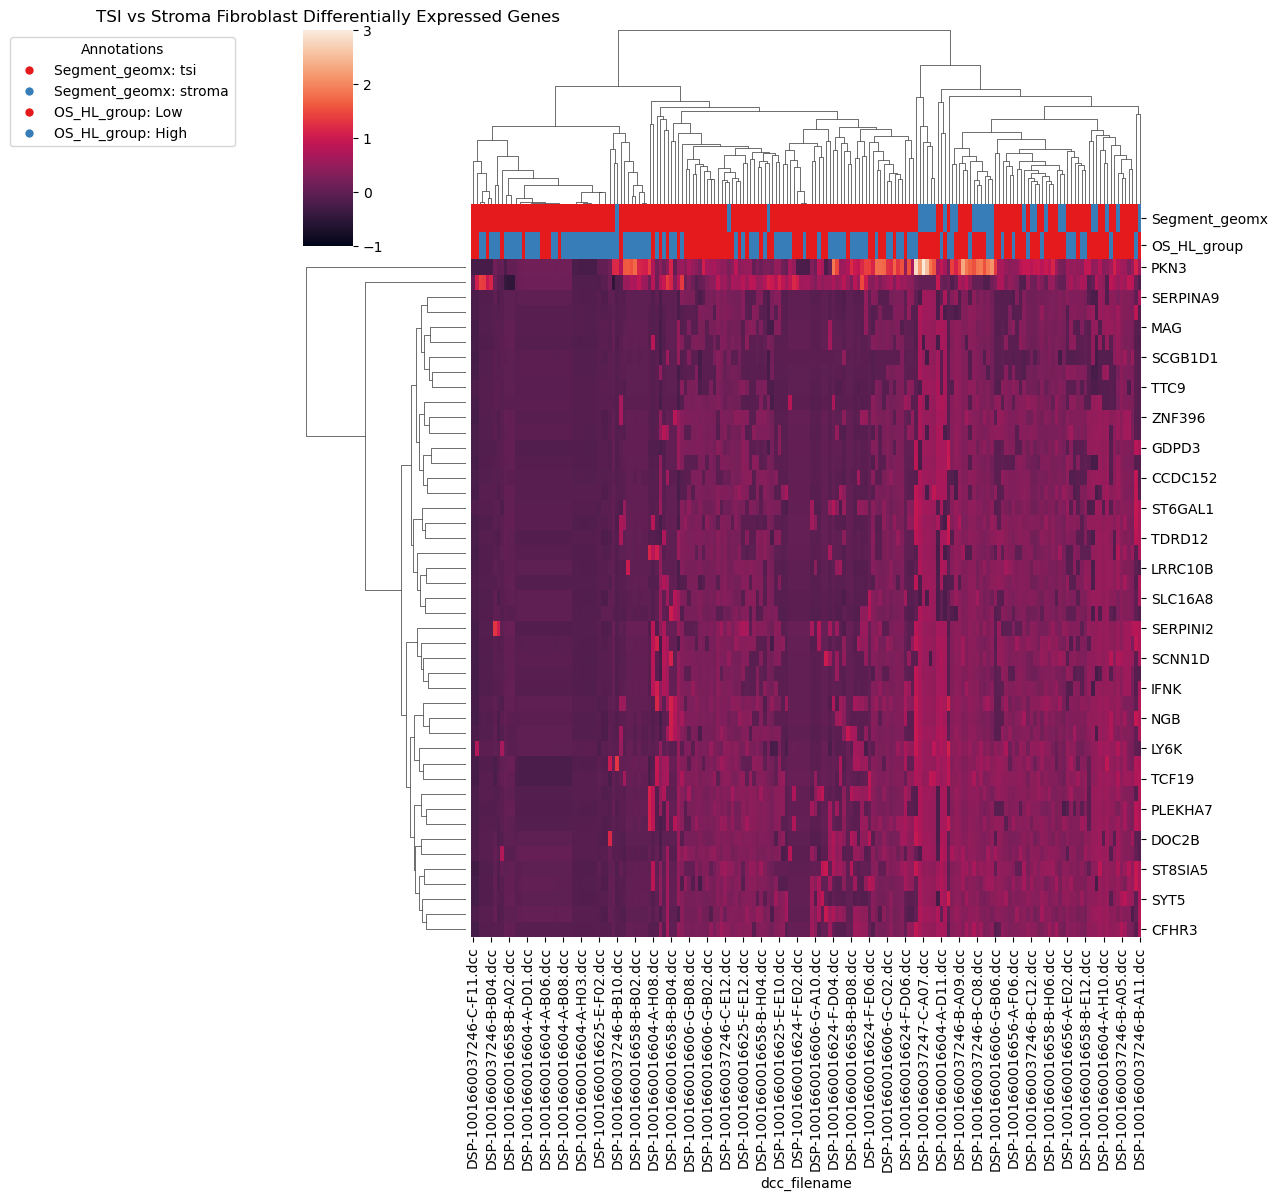

In [196]:
# Define variables to color by
color_vars = ["Segment_geomx","OS_HL_group"]

# Create a color map for each variable
colormaps = {
    var: sns.color_palette("Set1", len(merged_metadata[var].unique()))
    for var in color_vars
}

# Map categories to colors
color_maps = {
    var: {val: colormaps[var][i] for i, val in enumerate(merged_metadata[var].unique())}
    for var in color_vars
}

# Create a DataFrame where each column is a color annotation for a variable
row_color_df = merged_metadata[color_vars].apply(lambda col: col.map(color_maps[col.name]))

# Now use this in the clustermap
g = sns.clustermap(
    data_to_plot.T,
    col_colors=row_color_df,
    method="complete",
    vmin=-1, vmax=3,
    figsize=(10, 12)
)

plt.title("TSI vs Stroma Fibroblast Differentially Expressed Genes")

# Legend handles
handles = []
labels = []

for var in color_vars:
    for val, color in color_maps[var].items():
        handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=7))
        labels.append(f"{var}: {val}")

# Add a combined legend
plt.legend(handles=handles, labels=labels, title="Annotations", bbox_to_anchor=(-6, 1), loc='upper left')

In [199]:
with open("/Users/nikamikhailava/Desktop/batch_merged_new/TSI_stroma_fibroblast_expression_top_genes.txt", "w") as f:
    for gene in top_hits["index"]:
        f.write(f"{gene}\n")


/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')


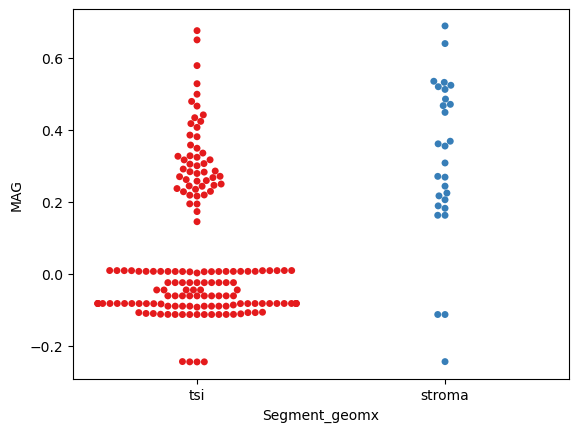

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')


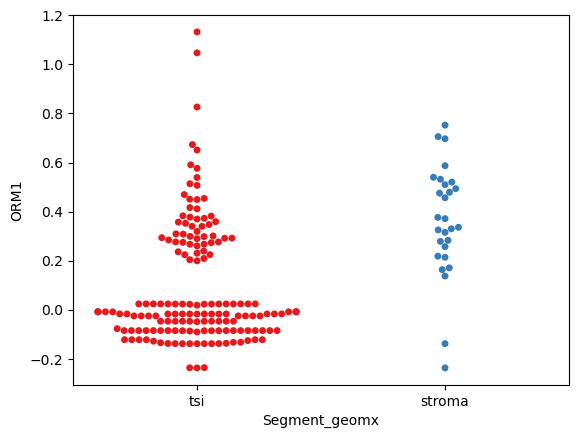

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')


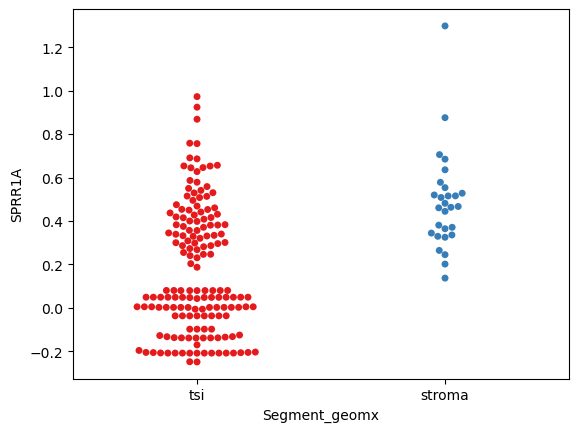

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')
/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 13.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


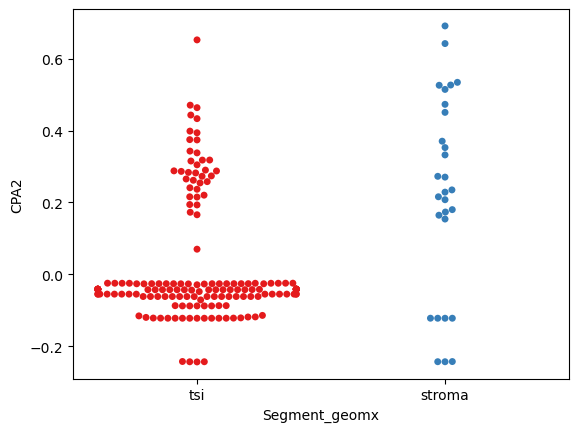

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')


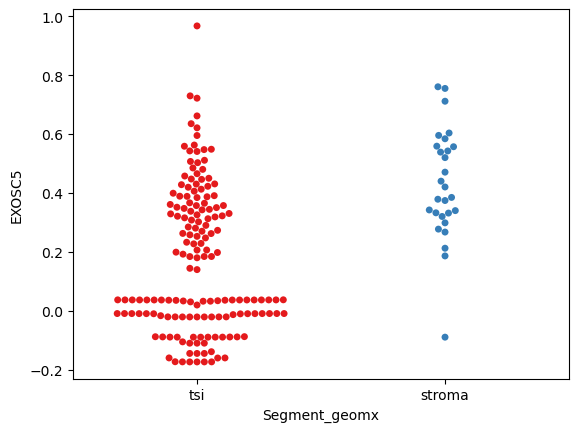

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')
/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 13.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


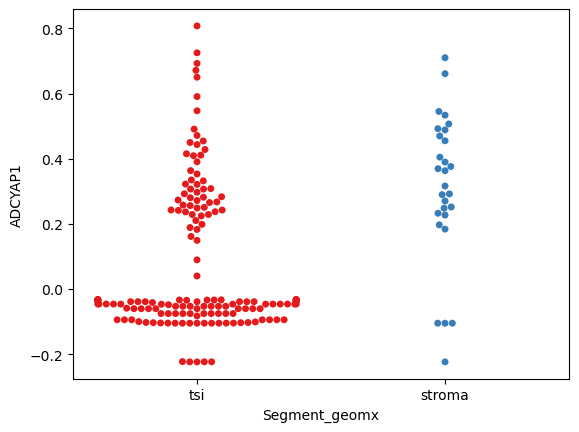

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')
/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 8.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


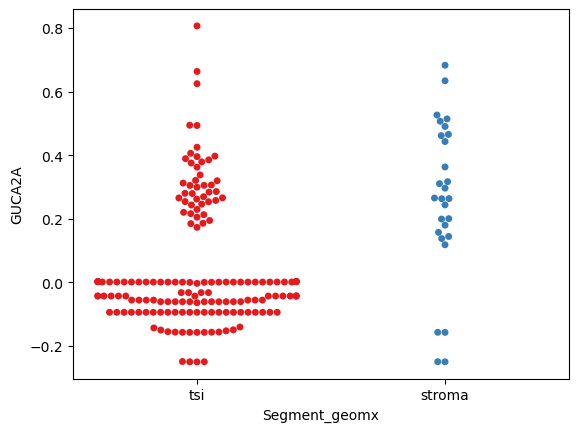

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')
/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 8.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


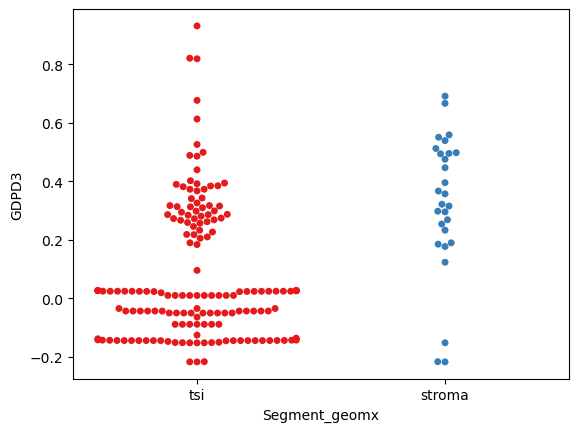

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')
/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 7.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


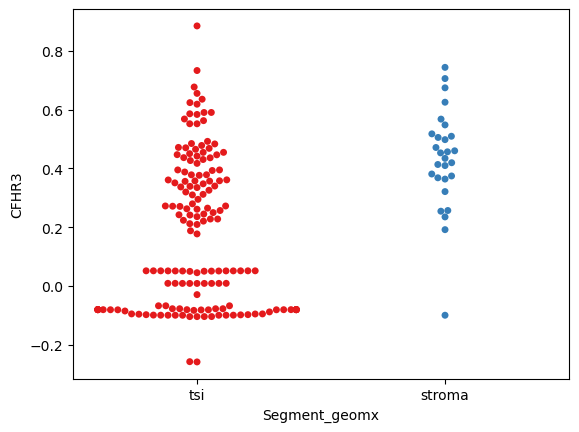

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')
/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 13.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


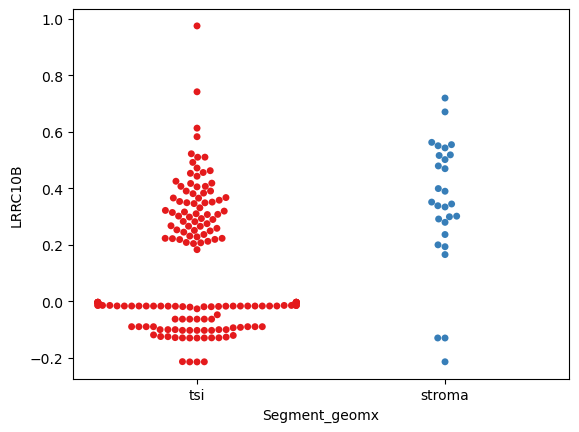

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')


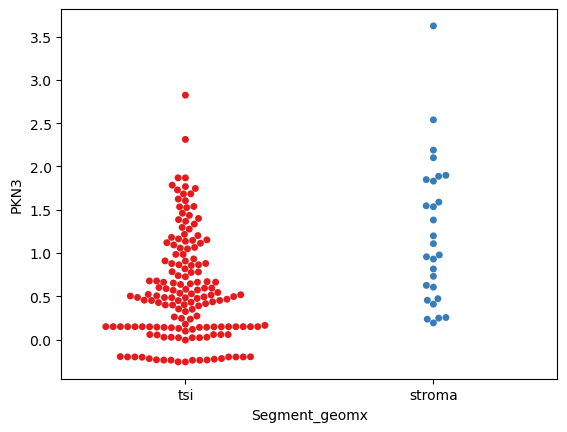

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')


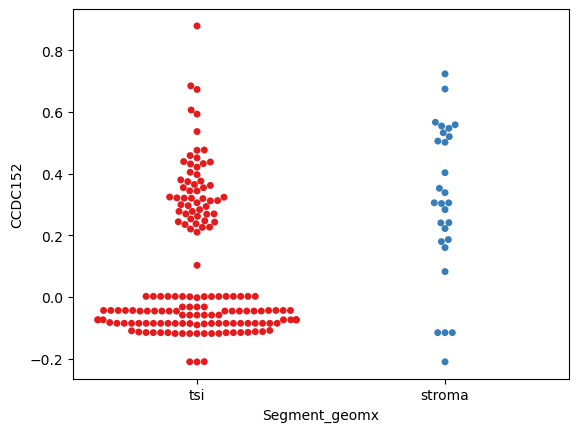

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')


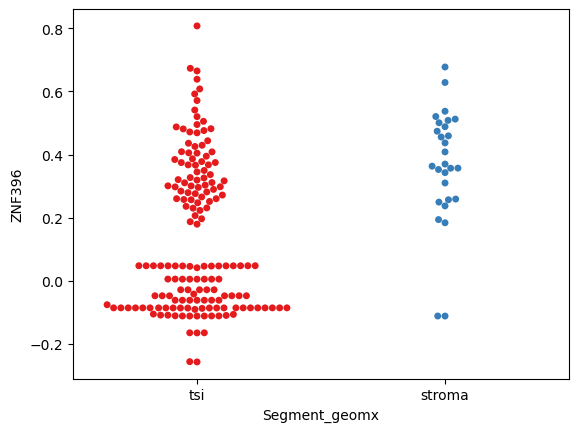

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')
/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 5.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


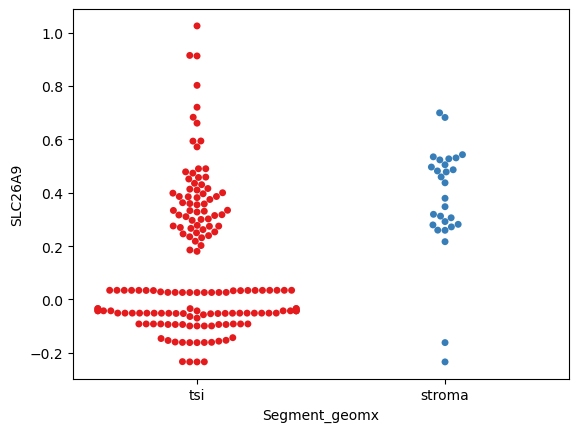

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')


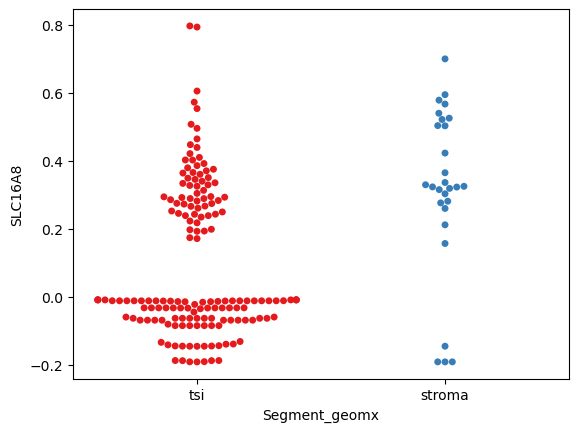

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')
/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 14.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


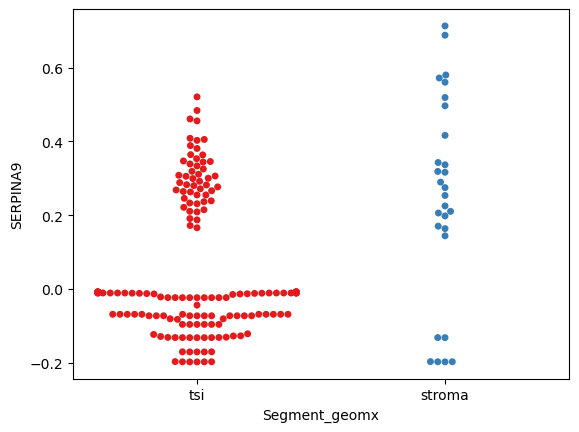

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')


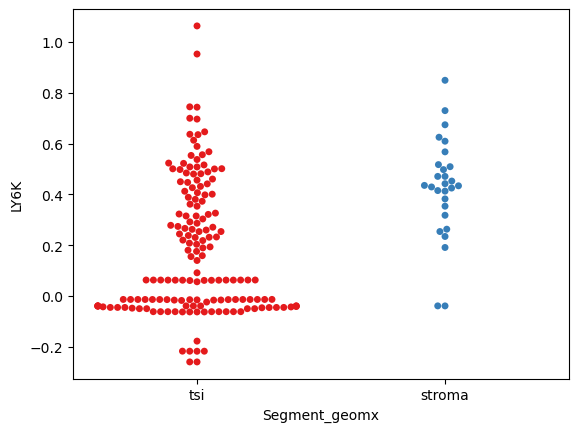

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')


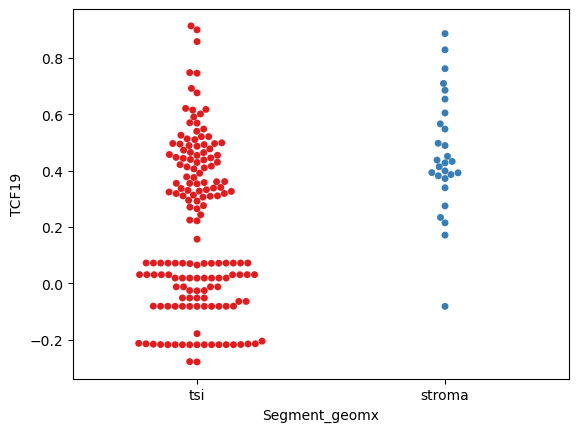

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')


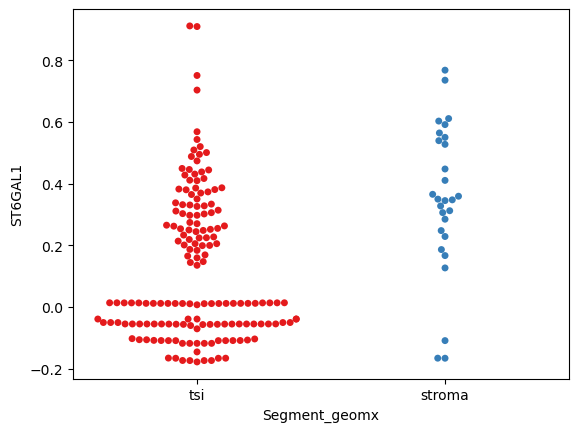

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')
/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 15.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


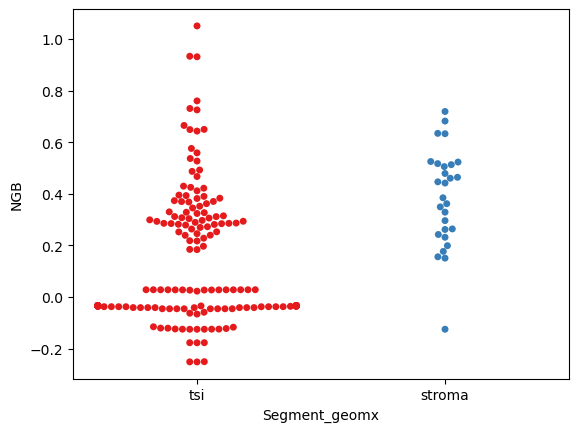

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')


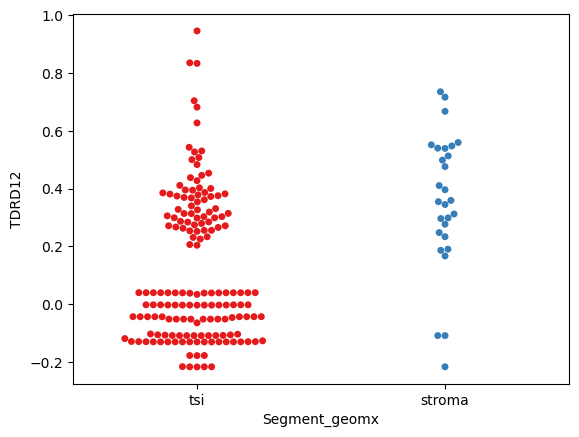

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')


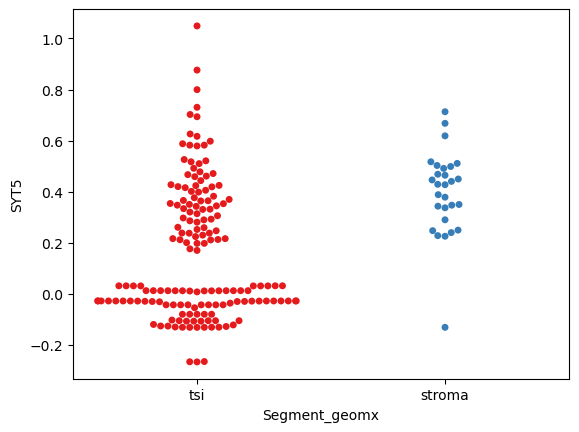

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')
/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 7.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


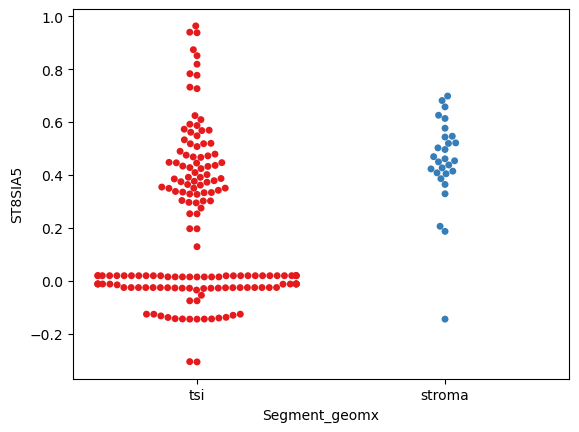

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')
/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 10.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


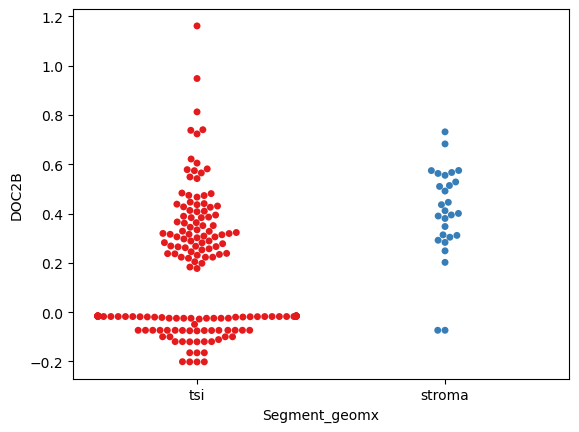

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')


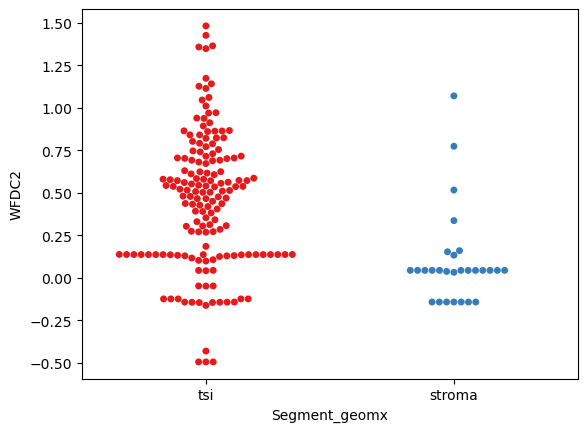

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')
/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 17.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 31.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


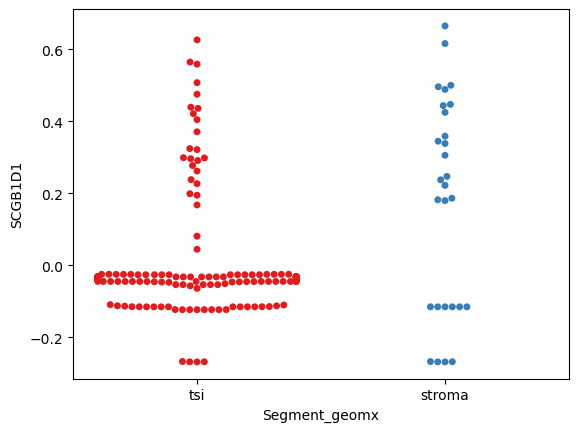

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')


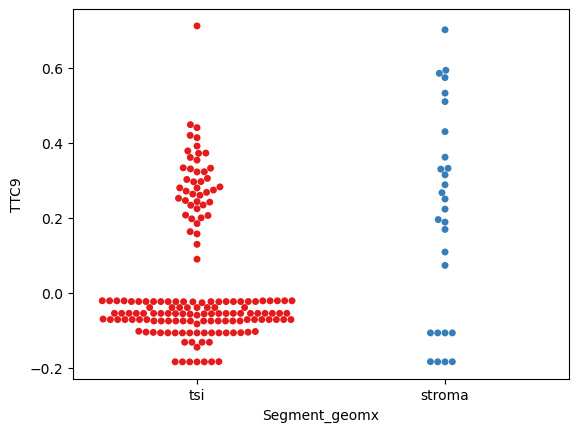

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')
/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 7.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


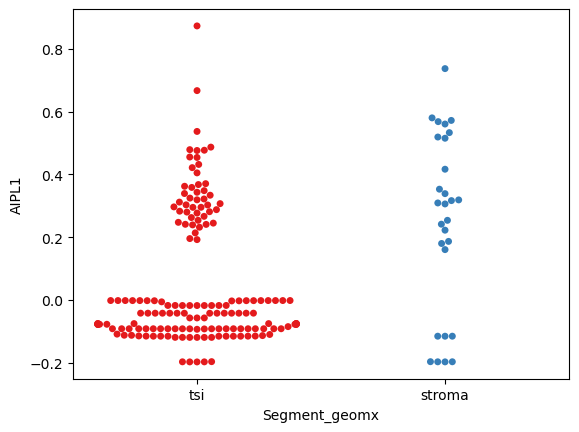

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')


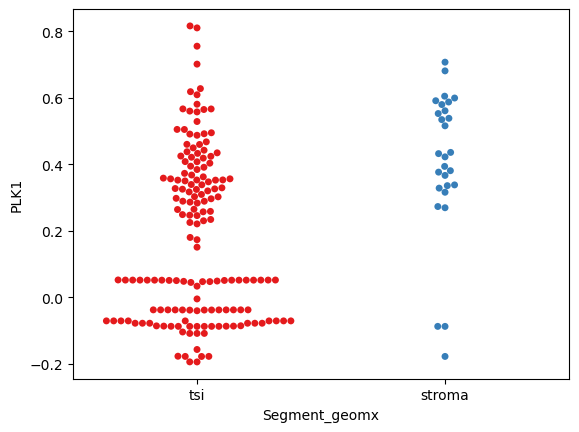

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')


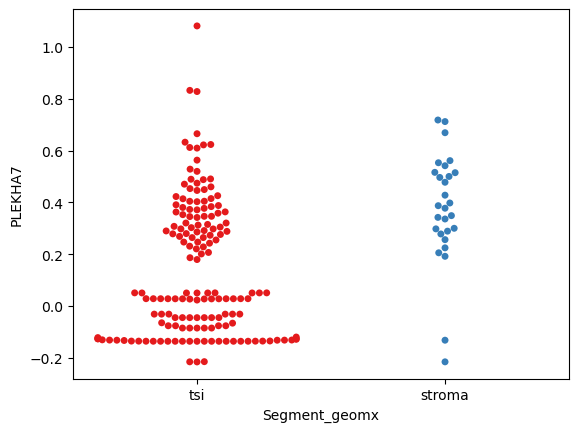

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')


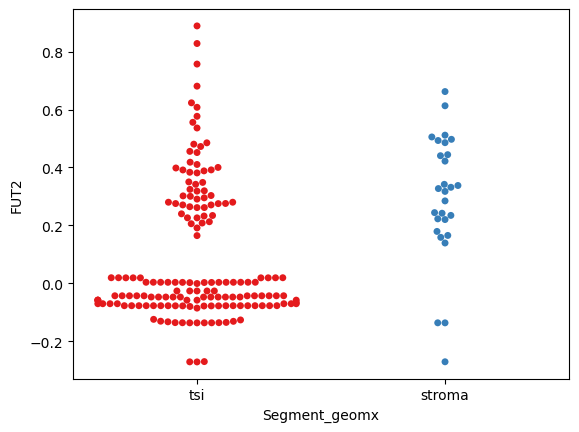

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')


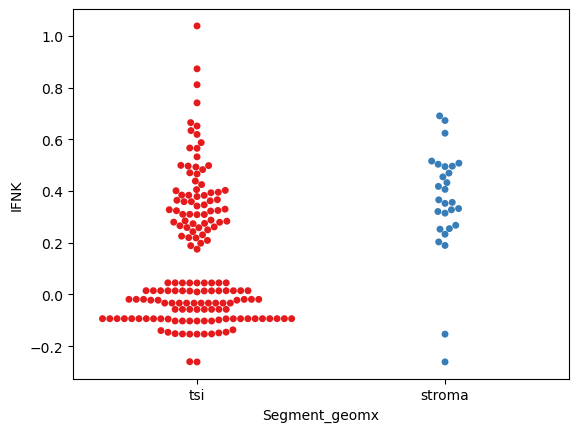

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')


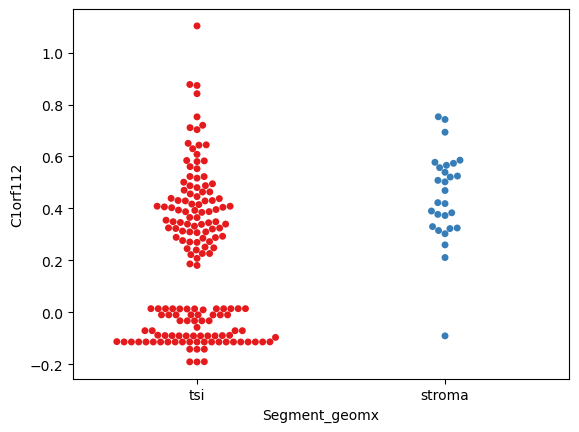

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')


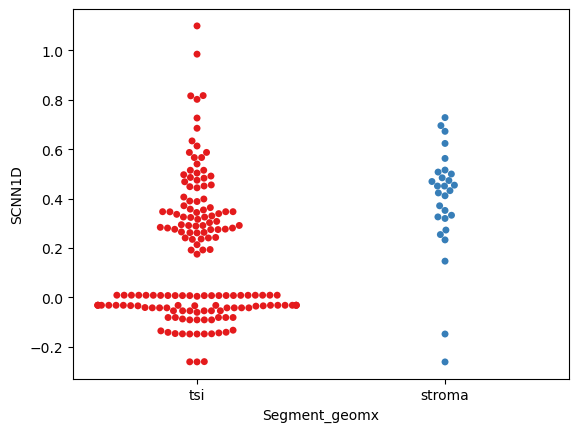

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')
/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 8.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


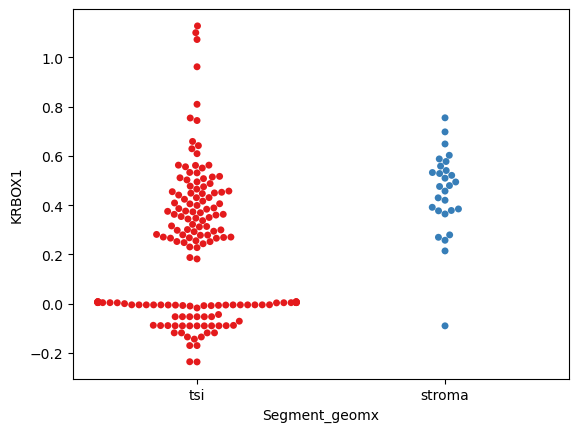

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')


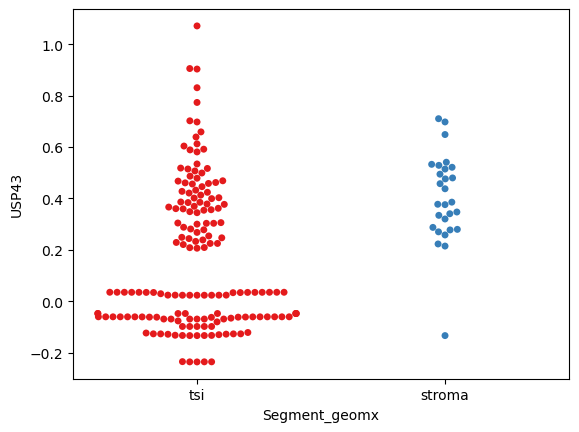

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')
/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 6.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


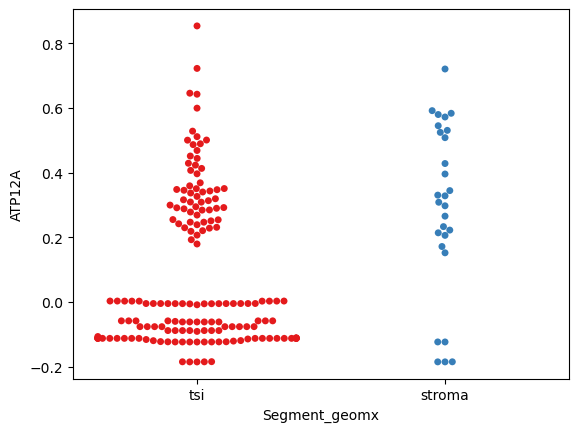

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')
/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 5.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


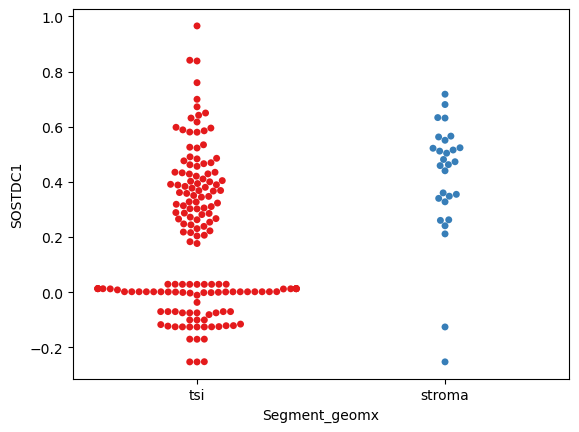

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')
/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 6.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


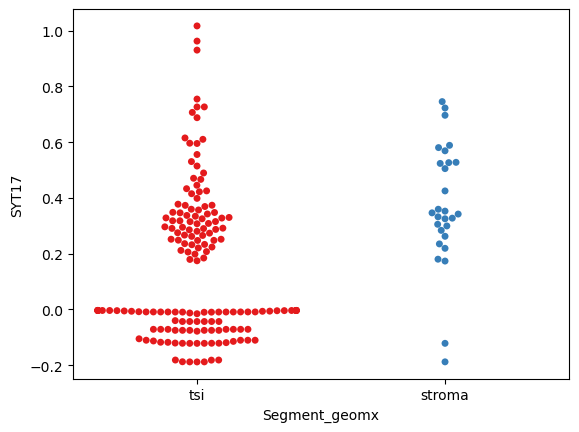

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')
/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 9.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


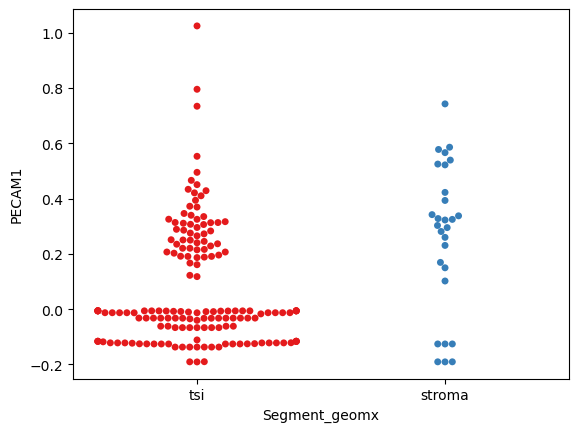

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')


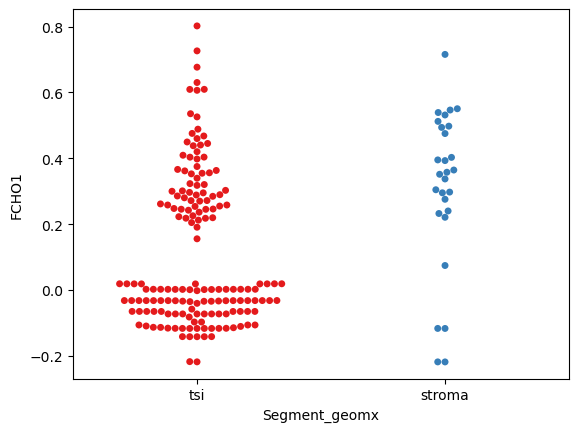

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')
/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 17.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


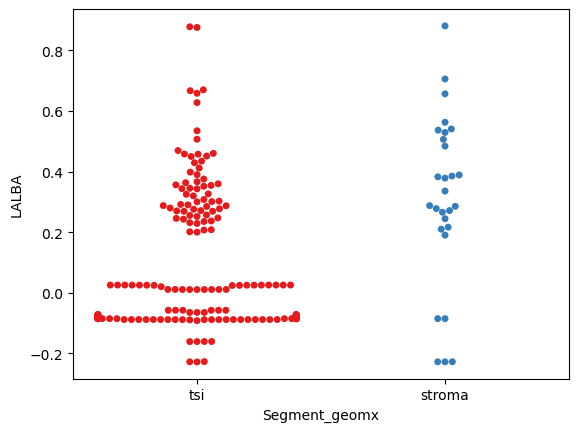

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')
/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 6.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


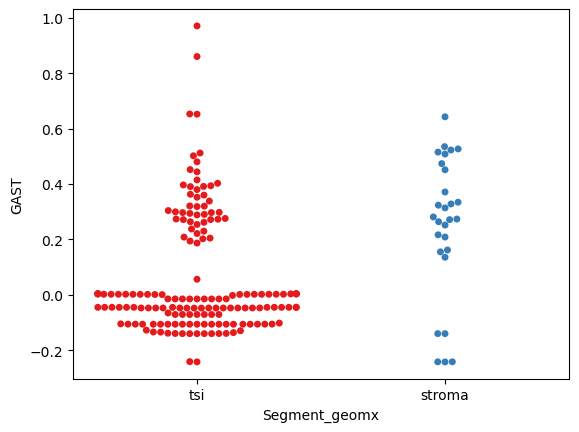

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')


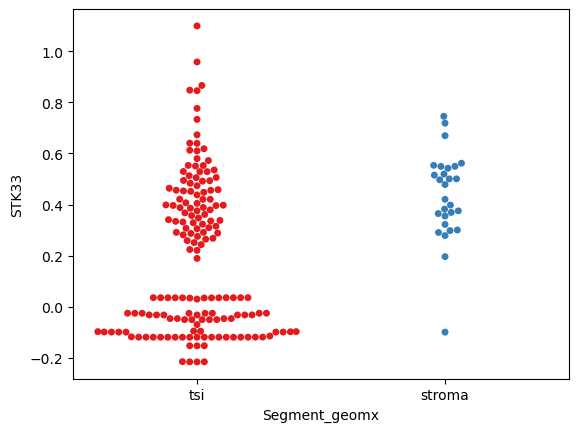

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_34624/3202828424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')


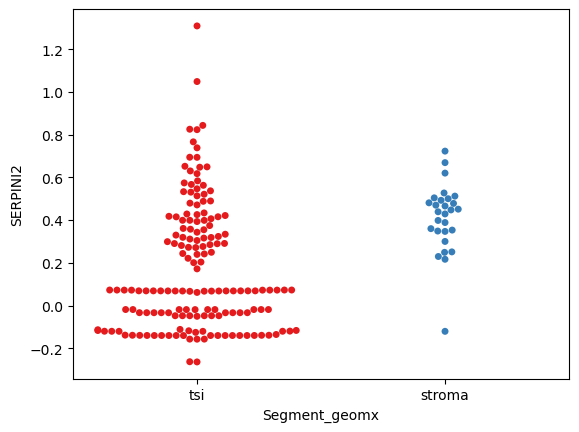

In [197]:

for gene in top_hits["index"]:
    sns.swarmplot(x='Segment_geomx', y=gene, data=merged_metadata, palette='Set1')
    plt.show()
    #output_dir = "//Volumes/h30492/farkkilab2/4_CellCycle_Nika/geomx/Results/PNGs/"
    #filename = f"{output_dir}swarmplot_{gene}_Ki67_pRb.png"
    #plt.savefig(filename, dpi=300)